### Final dataset images count

In [2]:
from pathlib import Path

DATASET_PATH = Path("plant_disease_dataset")

# Valid image extensions
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def count_images_per_class(dataset_path: Path) -> None:
    """
    Count the number of image files inside each class folder.

    Expected dataset structure:
        dataset_path/
            class_1/
                img1.jpg
                img2.png
            class_2/
                img3.jpg
                ...

    Prints:
        - class names
        - number of images per class
        - total classes
        - total images
    """
    if not dataset_path.exists():
        print(f"Error: Dataset path does not exist -> {dataset_path}")
        return

    if not dataset_path.is_dir():
        print(f"Error: Provided path is not a folder -> {dataset_path}")
        return

    class_folders = sorted([folder for folder in dataset_path.iterdir() if folder.is_dir()])

    if not class_folders:
        print(f"No class folders found inside: {dataset_path}")
        return

    total_images = 0

    print(f"\nDataset path: {dataset_path}")

    print("Classes and image counts:\n")

    for class_folder in class_folders:
        image_count = sum(
            1 for file in class_folder.rglob("*")
            if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
        )

        print(f"{class_folder.name}: {image_count} images")
        total_images += image_count

   
    print(f"Total classes: {len(class_folders)}")
    print(f"Total images : {total_images}")


if __name__ == "__main__":
    count_images_per_class(DATASET_PATH)


Dataset path: plant_disease_dataset
Classes and image counts:

Mango_Anthracnose: 431 images
Mango_Healthy: 353 images
Mango_Powdery_Mildew: 454 images
Pepper_Bacterial_Spot: 500 images
Pepper_Healthy: 499 images
Potato_Early_Blight: 500 images
Potato_Healthy: 499 images
Potato_Late_Blight: 500 images
Tomato_Early_Blight: 500 images
Tomato_Healthy: 499 images
Tomato_Late_Blight: 500 images
Tomato_Leaf_Mold: 500 images
Tomato_Yellow_leaf_curl_virus: 499 images
Total classes: 13
Total images : 6234


### Split new dataset

In [1]:
import os
import shutil
import random
from pathlib import Path

# CONFIG
INPUT_DATASET = Path("/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset")
OUTPUT_DATASET = Path("plant_disease_dataset_second_split")

TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

SEED = 42
ALLOWED_EXTS = (".jpg", ".jpeg", ".png")

random.seed(SEED)

# CREATE OUTPUT STRUCTURE
for split in ["train", "val", "test"]:
    (OUTPUT_DATASET / split).mkdir(parents=True, exist_ok=True)

# SPLIT FUNCTION
def split_class(class_path, class_name):

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(ALLOWED_EXTS)
    ]

    if len(images) == 0:
        print(f" Skipping empty folder: {class_path}")
        return

    random.shuffle(images)

    total = len(images)
    train_end = int(total * TRAIN_RATIO)
    val_end = int(total * (TRAIN_RATIO + VAL_RATIO))

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    # Create class folders (FLAT STRUCTURE)
    for split in ["train", "val", "test"]:
        (OUTPUT_DATASET / split / class_name).mkdir(parents=True, exist_ok=True)

    def copy_files(file_list, split_name):
        for img in file_list:
            src = class_path / img
            dst = OUTPUT_DATASET / split_name / class_name / img

            try:
                shutil.copy2(src, dst)
            except Exception as e:
                print(f"Error copying {src}: {e}")

    copy_files(train_imgs, "train")
    copy_files(val_imgs, "val")
    copy_files(test_imgs, "test")

    print(f"\n {class_name}")
    print(f"Train: {len(train_imgs)} | Val: {len(val_imgs)} | Test: {len(test_imgs)}")

# MAIN LOGIC (AUTO DETECT STRUCTURE)

for item in INPUT_DATASET.iterdir():

    if not item.is_dir():
        continue

    # CASE 1: Flat dataset (BEST)
    if any(f.suffix.lower() in ALLOWED_EXTS for f in item.iterdir()):
        split_class(item, item.name)

    # CASE 2: Nested dataset
    else:
        for sub in item.iterdir():
            if sub.is_dir():
                class_name = f"{item.name}_{sub.name}"
                split_class(sub, class_name)

# DONE

print("\n Dataset split complete.")
print(f"Saved to: {OUTPUT_DATASET.resolve()}")


 Tomato_Healthy
Train: 349 | Val: 75 | Test: 75

 Pepper_Bacterial_Spot
Train: 350 | Val: 75 | Test: 75

 Tomato_Early_Blight
Train: 350 | Val: 75 | Test: 75

 Tomato_Yellow_leaf_curl_virus
Train: 349 | Val: 75 | Test: 75

 Mango_Healthy
Train: 247 | Val: 53 | Test: 53

 Pepper_Healthy
Train: 349 | Val: 75 | Test: 75

 Potato_Late_Blight
Train: 350 | Val: 75 | Test: 75

 Tomato_Leaf_Mold
Train: 350 | Val: 75 | Test: 75

 Mango_Anthracnose
Train: 301 | Val: 65 | Test: 65

 Potato_Early_Blight
Train: 350 | Val: 75 | Test: 75

 Potato_Healthy
Train: 349 | Val: 75 | Test: 75

 Mango_Powdery_Mildew
Train: 317 | Val: 68 | Test: 69

 Tomato_Late_Blight
Train: 350 | Val: 75 | Test: 75

 Dataset split complete.
Saved to: /Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset_second_split


### Table for report evidence

In [4]:
from pathlib import Path
import csv


DATASET_PATH = Path("plant_disease_dataset_split")

# Accepted image file extensions
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Folder names to check
TRAIN_FOLDER = "train"
VAL_FOLDER_CANDIDATES = ["validation", "val"]
TEST_FOLDER = "test"


def count_images_in_class_folder(folder: Path) -> int:
    """Count valid image files inside a class folder."""
    if not folder.exists() or not folder.is_dir():
        return 0

    return sum(
        1
        for file in folder.rglob("*")
        if file.is_file() and file.suffix.lower() in IMAGE_EXTENSIONS
    )


def find_validation_folder(dataset_path: Path) -> str | None:
    """Return the validation folder name if found."""
    for name in VAL_FOLDER_CANDIDATES:
        if (dataset_path / name).exists():
            return name
    return None


def generate_dataset_table(dataset_path: Path):
    """Generate class-wise counts for train, validation, test, and total."""
    if not dataset_path.exists():
        print(f"Error: Dataset path does not exist -> {dataset_path}")
        return []

    train_path = dataset_path / TRAIN_FOLDER
    test_path = dataset_path / TEST_FOLDER
    val_folder_name = find_validation_folder(dataset_path)

    if not train_path.exists():
        print("Error: 'train' folder not found.")
        return []

    if not test_path.exists():
        print("Error: 'test' folder not found.")
        return []

    if val_folder_name is None:
        print("Error: No 'validation' or 'val' folder found.")
        return []

    val_path = dataset_path / val_folder_name

    # Collect all unique class names across the three subsets
    class_names = set()

    for subset_path in [train_path, val_path, test_path]:
        if subset_path.exists():
            for item in subset_path.iterdir():
                if item.is_dir():
                    class_names.add(item.name)

    class_names = sorted(class_names)

    table_rows = []

    for class_name in class_names:
        train_count = count_images_in_class_folder(train_path / class_name)
        val_count = count_images_in_class_folder(val_path / class_name)
        test_count = count_images_in_class_folder(test_path / class_name)
        total_count = train_count + val_count + test_count

        table_rows.append([
            class_name,
            train_count,
            val_count,
            test_count,
            total_count
        ])

    return table_rows


def print_markdown_table(rows):
    """Print the table in Markdown format for easy copy into report."""
    print("\n| Class | Training | Validation | Test | Total |")
    print("|----------------------------------------------|")
    for row in rows:
        print(f"| {row[0]} | {row[1]} | {row[2]} | {row[3]} | {row[4]} |")


def save_csv(rows, filename="dataset_composition_table.csv"):
    """Save the table as a CSV file."""
    with open(filename, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["Class", "Training", "Validation", "Test", "Total"])
        writer.writerows(rows)
    print(f"\nCSV table saved as: {filename}")


if __name__ == "__main__":
    rows = generate_dataset_table(DATASET_PATH)

    if rows:
        print_markdown_table(rows)
        save_csv(rows)


| Class | Training | Validation | Test | Total |
|----------------------------------------------|
| Mango_Anthracnose | 301 | 65 | 65 | 431 |
| Mango_Healthy | 247 | 53 | 53 | 353 |
| Mango_Powdery_Mildew | 317 | 68 | 69 | 454 |
| Pepper_Bacterial_Spot | 349 | 75 | 75 | 499 |
| Pepper_Healthy | 349 | 75 | 75 | 499 |
| Potato_Early_blight | 349 | 75 | 75 | 499 |
| Potato_Healthy | 349 | 75 | 75 | 499 |
| Potato_Late_blight | 349 | 75 | 75 | 499 |
| Tomato_Early_Blight | 350 | 75 | 75 | 500 |
| Tomato_Healthy | 349 | 75 | 75 | 499 |
| Tomato_Late_Blight | 350 | 75 | 75 | 500 |
| Tomato_Leaf_Mold | 349 | 75 | 75 | 499 |
| Tomato_Yellow_leaf_curl_virus | 349 | 75 | 75 | 499 |

CSV table saved as: dataset_composition_table.csv


### Training on modified dataset

This script is on 10 epochs for 224 x 224 image pixels

### 1st training


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# PATHS
train_dir = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset_second_split/train"
val_dir = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset_second_split/val"
test_dir = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset_second_split/test"

os.makedirs("models_second", exist_ok=True)

# SETTINGS
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# DATA LOADERS
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)
class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)
print("Number of classes:", num_classes)

# PERFORMANCE OPTIMISATION
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# DATA AUGMENTATION (TRAIN ONLY)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])
# BASE MODEL
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # Stage 1: freeze backbone

# BUILD MODEL
inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

# COMPILE STAGE 1
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# CALLBACKS
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="models_second/best_stage1_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

# TRAIN STAGE 1
print("\nStarting Stage 1 training...")
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

# STAGE 2: FINE-TUNING
base_model.trainable = True

# Freeze most layers, unfreeze top layers only
fine_tune_at = int(len(base_model.layers) * 0.8)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_finetune = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="models_second/best_finetuned_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("\nStarting Stage 2 fine-tuning...")
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=callbacks_finetune
)

# FINAL EVALUATION
print("\nEvaluating on test set...")
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# SAVE FINAL MODEL
final_model_path = "models_second/plant_disease_model_final.keras"
model.save(final_model_path)
print(f"\nFinal model saved to: {final_model_path}")

# SAVE CLASS NAMES
class_names_path = "models_second/class_names.txt"
with open(class_names_path, "w", encoding="utf-8") as f:
    for name in class_names:
        f.write(name + "\n")

print(f"Class names saved to: {class_names_path}")

Found 4361 files belonging to 13 classes.
Found 936 files belonging to 13 classes.
Found 937 files belonging to 13 classes.
Classes: ['Mango_Anthracnose', 'Mango_Healthy', 'Mango_Powdery_Mildew', 'Pepper_Bacterial_Spot', 'Pepper_Healthy', 'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Yellow_leaf_curl_virus']
Number of classes: 13

Starting Stage 1 training...
Epoch 1/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.6540 - loss: 1.1118
Epoch 1: val_loss improved from None to 0.37268, saving model to models_second/best_stage1_model.keras

Epoch 1: finished saving model to models_second/best_stage1_model.keras
137/137 ━━━━━━━━━━━━━━━━━━━━ 80s 549ms/step - accuracy: 0.7870 - loss: 0.6583 - val_accuracy: 0.9316 - val_loss: 0.3727 - learning_rate: 0.0010
Epoch 2/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.9157 - loss: 0.2551
Epoch 2: val_loss improved from 0.

2026-03-24 00:36:08.243596: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 469ms/step
Classes: ['Mango_Anthracnose', 'Mango_Healthy', 'Mango_Powdery_Mildew', 'Pepper_Bacterial_Spot', 'Pepper_Healthy', 'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Yellow_leaf_curl_virus']

Classification Report:

                               precision    recall  f1-score   support

            Mango_Anthracnose     1.0000    1.0000    1.0000        65
                Mango_Healthy     1.0000    1.0000    1.0000        53
         Mango_Powdery_Mildew     1.0000    1.0000    1.0000        69
        Pepper_Bacterial_Spot     0.9740    1.0000    0.9868        75
               Pepper_Healthy     0.9737    0.9867    0.9801        75
          Potato_Early_Blight     1.0000    1.0000    1.0000        75
               Potato_Healthy     0.9737    0.9867    0.9801        75
           Potato_Late_Blight     0.9861    0.9467    0.9660        75

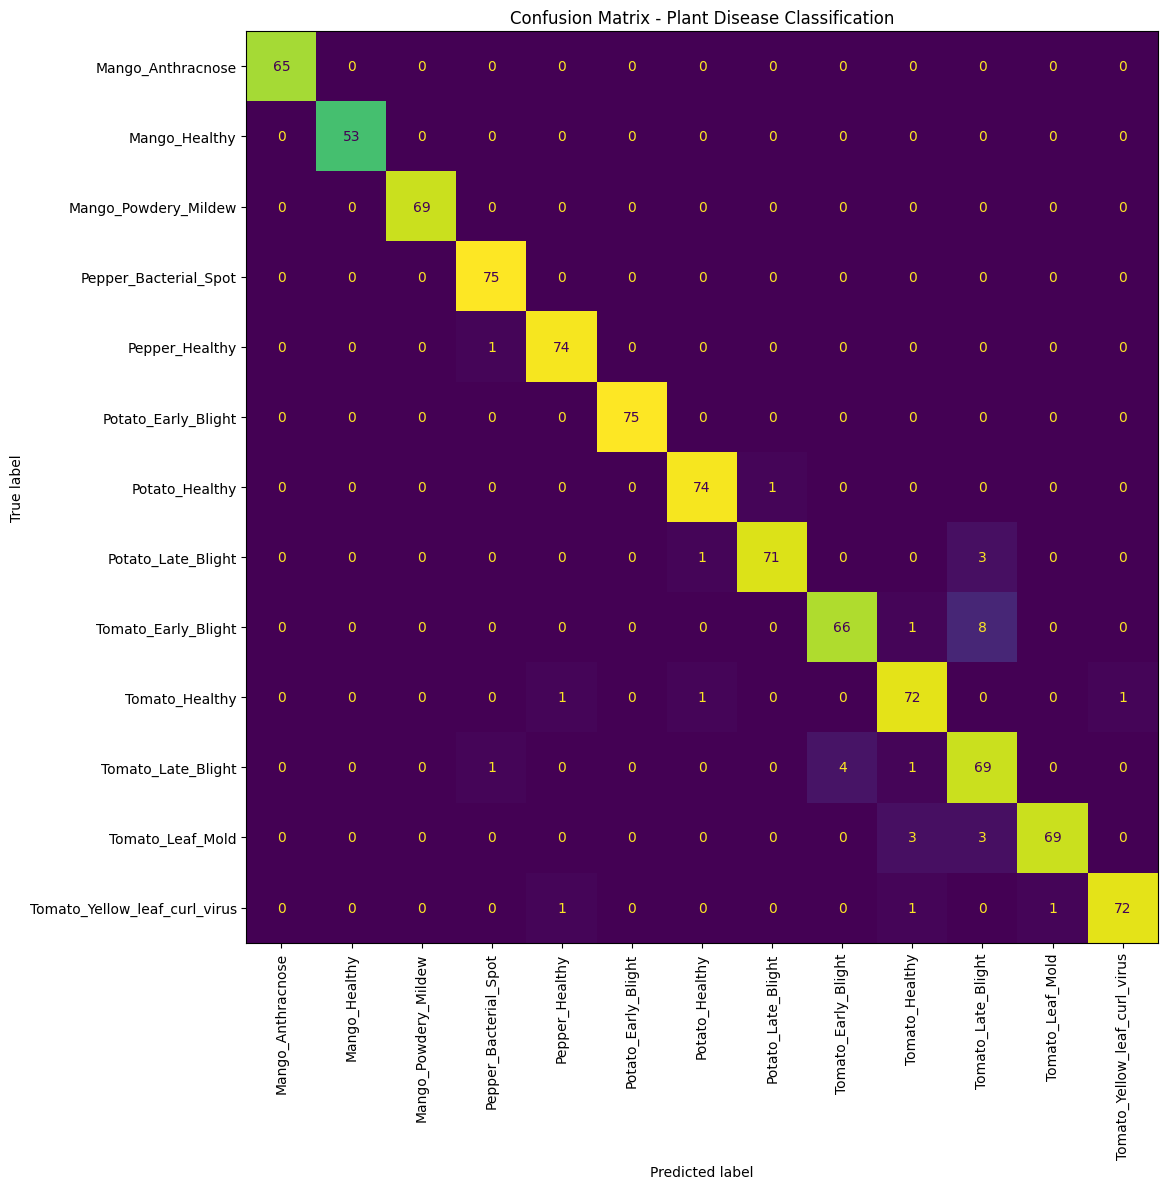

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model

# LOAD BEST MODEL
model = load_model("/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/models_second/best_stage1_model.keras")

# GET TRUE LABELS
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

# GET PREDICTIONS
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# CLASS NAMES
with open("models_second/class_names.txt", "r") as f:
    class_names = [line.strip() for line in f.readlines()]
print("Classes:", class_names)

# CLASSIFICATION REPORT
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("\nClassification Report:\n")
print(report)

# Optional: save report to a text file
with open("models_second/classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

# CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, values_format="d", colorbar=False)
plt.title("Confusion Matrix - Plant Disease Classification")
plt.tight_layout()
plt.show()

# Optional: save confusion matrix image
fig.savefig("models_second/confusion_matrix.png", dpi=300, bbox_inches="tight")

### Testing on small dataset

Loaded class names:
['Mango_Anthracnose', 'Mango_Healthy', 'Mango_Powdery_Mildew', 'Pepper_Bacterial_Spot', 'Pepper_Healthy', 'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Yellow_leaf_curl_virus']
Found 65 files belonging to 13 classes.

External dataset class names detected:
['Mango_Anthracnose', 'Mango_Healthy', 'Mango_Powdery_Mildew', 'Pepper_Bacterial_Spot', 'Pepper_Healthy', 'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Yellow_leaf_curl_virus']


2026-03-24 00:41:05.984386: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 426ms/step

Classification Report on External Test Dataset:

                               precision    recall  f1-score   support

            Mango_Anthracnose     1.0000    0.6000    0.7500         5
                Mango_Healthy     1.0000    0.4000    0.5714         5
         Mango_Powdery_Mildew     0.5000    0.2000    0.2857         5
        Pepper_Bacterial_Spot     0.5556    1.0000    0.7143         5
               Pepper_Healthy     0.7143    1.0000    0.8333         5
          Potato_Early_Blight     1.0000    0.4000    0.5714         5
               Potato_Healthy     0.3846    1.0000    0.5556         5
           Potato_Late_Blight     0.4286    0.6000    0.5000         5
          Tomato_Early_Blight     0.5000    0.2000    0.2857         5
               Tomato_Healthy     0.4286    0.6000    0.5000         5
           Tomato_Late_Blight     0.3333    0.6000    0.4286         5
             Tomato_Leaf_Mold     1.0000    0.2000    0.33

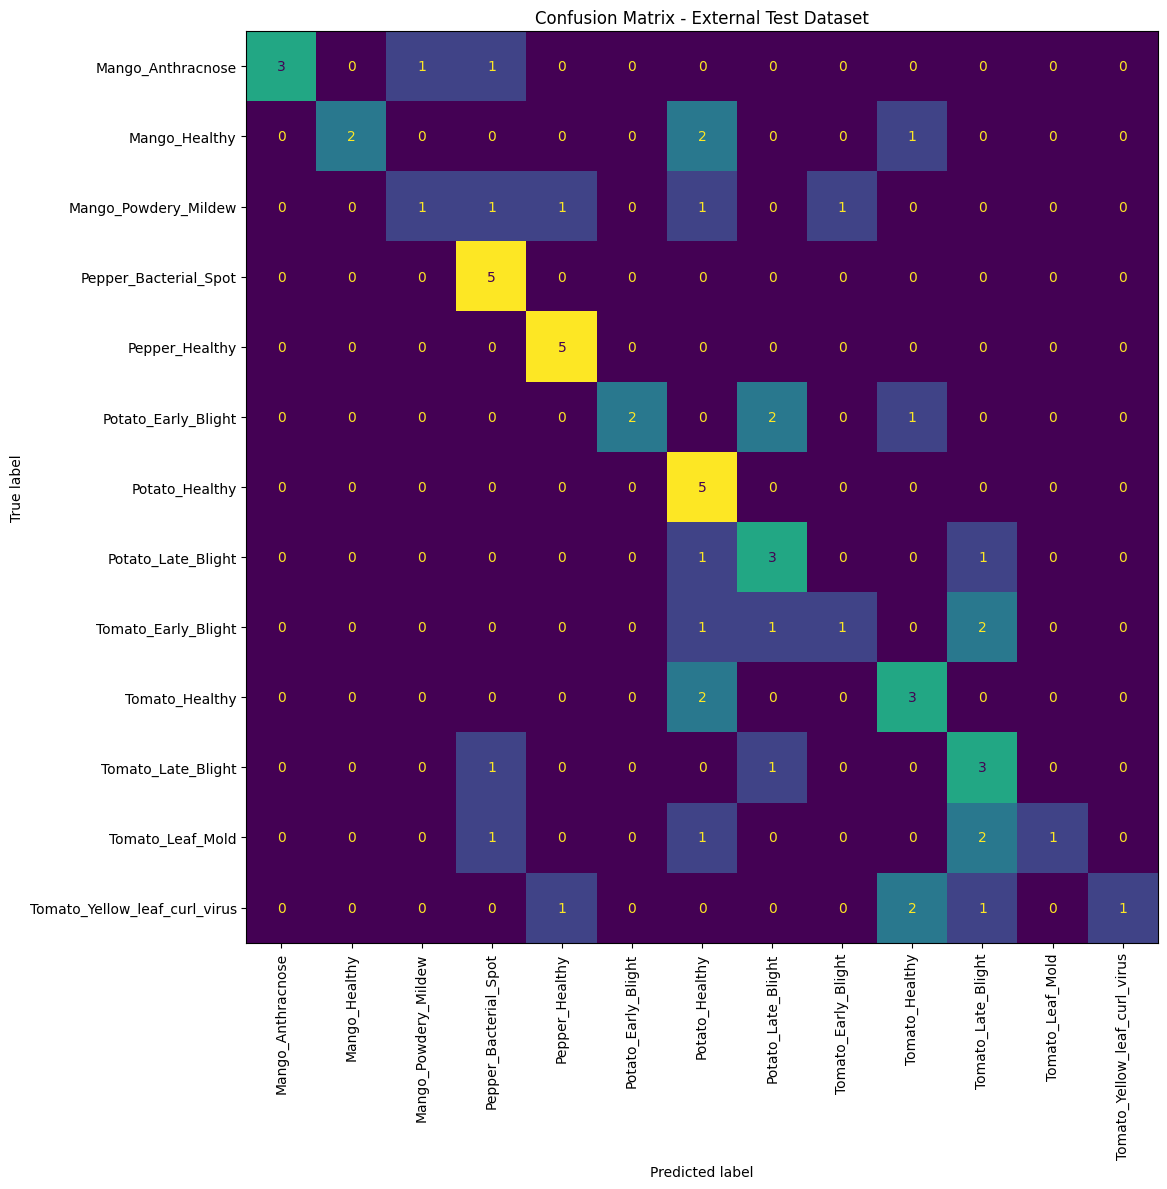


Per-image predictions:

File: /Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/mini_dataset/Mango_Anthracnose/Mango_Anthracnose_0001.png
True: Mango_Anthracnose
Pred: Mango_Powdery_Mildew
Confidence: 0.8363
--------------------------------------------------
File: /Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/mini_dataset/Mango_Anthracnose/Mango_Anthracnose_0002.png
True: Mango_Anthracnose
Pred: Mango_Anthracnose
Confidence: 0.5813
--------------------------------------------------
File: /Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/mini_dataset/Mango_Anthracnose/Mango_Anthracnose_0003.png
True: Mango_Anthracnose
Pred: Mango_Anthracnose
Confidence: 0.9987
--------------------------------------------------
File: /Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/mini_dataset/Mango_Anthracnose/Mango_Anthracnose_0004.png
True: Mango_Anthra

In [5]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model

# ============================================================
# PATHS
# ============================================================
MODEL_PATH = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/models_second/best_stage1_model.keras"
# /Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/models_second/best_stage1_model_tuned.keras
CLASS_NAMES_PATH = "models_second/class_names.txt"
EXTERNAL_TEST_DIR = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/mini_dataset"

# ============================================================
# SETTINGS
# ============================================================
IMG_SIZE = (224, 224)
# IMG_SIZE = (300, 300)  # if model was trained with 300x300
BATCH_SIZE = 16

# ============================================================
# LOAD MODEL
# ============================================================
model = load_model(MODEL_PATH)

# ============================================================
# LOAD SAVED CLASS NAMES
# ============================================================
with open(CLASS_NAMES_PATH, "r", encoding="utf-8") as f:
    class_names = [line.strip() for line in f.readlines()]

print("Loaded class names:")
print(class_names)

# ============================================================
# LOAD EXTERNAL DATASET
# ============================================================
external_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    EXTERNAL_TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nExternal dataset class names detected:")
print(external_ds_raw.class_names)

AUTOTUNE = tf.data.AUTOTUNE
external_ds = external_ds_raw.prefetch(buffer_size=AUTOTUNE)

# ============================================================
# TRUE LABELS
# ============================================================
y_true = np.concatenate([y.numpy() for _, y in external_ds], axis=0)

# ============================================================
# PREDICTIONS
# ============================================================
y_pred_probs = model.predict(external_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# ============================================================
# CLASSIFICATION REPORT
# ============================================================
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("\nClassification Report on External Test Dataset:\n")
print(report)

# ============================================================
# CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, values_format="d", colorbar=False)
plt.title("Confusion Matrix - External Test Dataset")
plt.tight_layout()
plt.show()

# ============================================================
# PER-IMAGE PREDICTIONS
# ============================================================
file_paths = []
for class_dir in sorted(Path(EXTERNAL_TEST_DIR).iterdir()):
    if class_dir.is_dir():
        for img_file in sorted(class_dir.iterdir()):
            if img_file.is_file():
                file_paths.append(str(img_file))

print("\nPer-image predictions:\n")
for i, path in enumerate(file_paths):
    true_label = class_names[y_true[i]]
    pred_label = class_names[y_pred[i]]
    confidence = np.max(y_pred_probs[i])

    print(f"File: {path}")
    print(f"True: {true_label}")
    print(f"Pred: {pred_label}")
    print(f"Confidence: {confidence:.4f}")
    print("-" * 50)

### Second training

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# PATHS
train_dir = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset_second_split/train"
val_dir = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset_second_split/val"
test_dir = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset_second_split/test"

os.makedirs("models_second", exist_ok=True)

# SETTINGS
IMG_SIZE = (300, 300)
BATCH_SIZE = 16
SEED = 42

# DATA LOADERS
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)
class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)
print("Number of classes:", num_classes)

# PERFORMANCE OPTIMISATION
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# LIGHTER DATA AUGMENTATION
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
])
# BASE MODEL
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(300, 300, 3)
)
base_model.trainable = False
# BUILD MODEL
inputs = layers.Input(shape=(300, 300, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
model = models.Model(inputs, outputs)
# COMPILE STAGE 1
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
# CALLBACKS STAGE 1
callbacks_stage1 = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="models_second/best_stage1_model_tuned.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]
# TRAIN STAGE 1
print("\nStarting Stage 1 training...")
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=callbacks_stage1
)

# LOAD BEST STAGE 1 WEIGHTS BEFORE FINE-TUNING
model.load_weights("models_second/best_stage1_model_tuned.keras")

# STAGE 2: FINE-TUNING
base_model.trainable = True

# Unfreeze only top 10–15% of layers
fine_tune_at = int(len(base_model.layers) * 0.9)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_stage2 = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="models_second/best_finetuned_model_tuned.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("\nStarting Stage 2 fine-tuning...")
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=callbacks_stage2
)

# EVALUATE BEST STAGE 1 MODEL
print("\nEvaluating best Stage 1 model...")
stage1_best = tf.keras.models.load_model("models_second/best_stage1_model_tuned.keras")
stage1_loss, stage1_acc = stage1_best.evaluate(test_ds)
print(f"Best Stage 1 - Test Loss: {stage1_loss:.4f}")
print(f"Best Stage 1 - Test Accuracy: {stage1_acc:.4f}")

# EVALUATE BEST FINE-TUNED MODEL
print("\nEvaluating best fine-tuned model...")
stage2_best = tf.keras.models.load_model("models_second/best_finetuned_model_tuned.keras")
stage2_loss, stage2_acc = stage2_best.evaluate(test_ds)
print(f"Best Fine-Tuned - Test Loss: {stage2_loss:.4f}")
print(f"Best Fine-Tuned - Test Accuracy: {stage2_acc:.4f}")

# SAVE FINAL CHOSEN MODEL
if stage2_acc >= stage1_acc:
    final_model = stage2_best
    final_model_path = "models_second/plant_disease_model_final_tuned.keras"
    print("\nUsing fine-tuned model as final model.")
else:
    final_model = stage1_best
    final_model_path = "models_second/plant_disease_model_final_tuned.keras"
    print("\nUsing Stage 1 model as final model.")

final_model.save(final_model_path)
print(f"Final model saved to: {final_model_path}")

# SAVE CLASS NAMES
class_names_path = "models_second/class_names_tuned.txt"
with open(class_names_path, "w", encoding="utf-8") as f:
    for name in class_names:
        f.write(name + "\n")

print(f"Class names saved to: {class_names_path}")

Found 4361 files belonging to 13 classes.
Found 936 files belonging to 13 classes.
Found 937 files belonging to 13 classes.
Classes: ['Mango_Anthracnose', 'Mango_Healthy', 'Mango_Powdery_Mildew', 'Pepper_Bacterial_Spot', 'Pepper_Healthy', 'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Yellow_leaf_curl_virus']
Number of classes: 13

Starting Stage 1 training...
Epoch 1/12
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.7418 - loss: 0.8891
Epoch 1: val_loss improved from None to 0.17907, saving model to models_second/best_stage1_model_tuned.keras

Epoch 1: finished saving model to models_second/best_stage1_model_tuned.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 140s 496ms/step - accuracy: 0.8370 - loss: 0.5443 - val_accuracy: 0.9455 - val_loss: 0.1791 - learning_rate: 0.0010
Epoch 2/12
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.9238 - loss: 0.2333
Epoch 2: val_loss imp

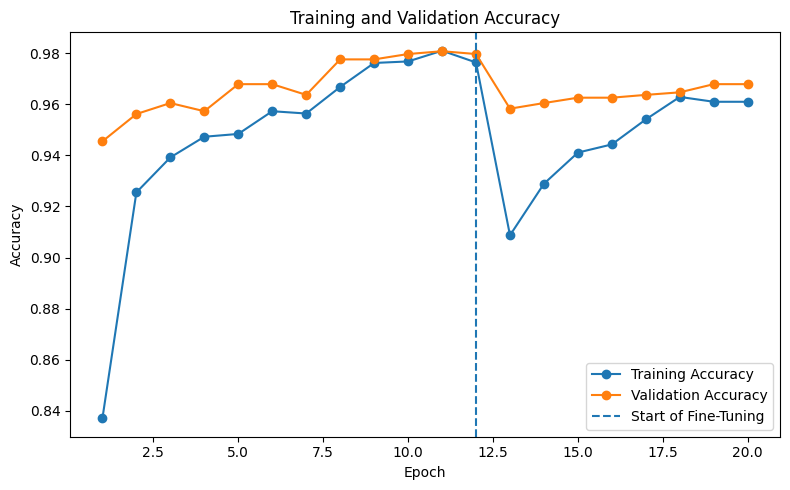

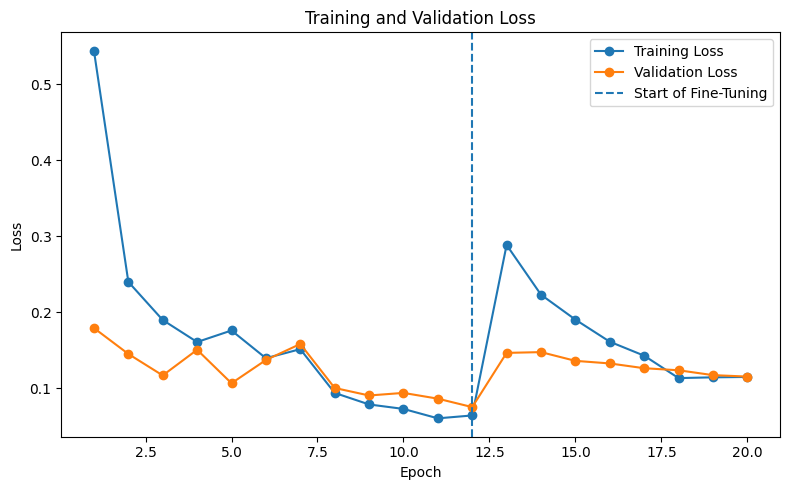

In [9]:
import matplotlib.pyplot as plt

# Stage 1 values extracted from training log
stage1_train_acc = [0.8370, 0.9255, 0.9392, 0.9473, 0.9484, 0.9573, 0.9564, 0.9668, 0.9762, 0.9768, 0.9810, 0.9764]
stage1_val_acc   = [0.9455, 0.9562, 0.9605, 0.9573, 0.9679, 0.9679, 0.9637, 0.9776, 0.9776, 0.9797, 0.9808, 0.9797]

stage1_train_loss = [0.5443, 0.2399, 0.1897, 0.1607, 0.1759, 0.1394, 0.1513, 0.0937, 0.0785, 0.0726, 0.0602, 0.0640]
stage1_val_loss   = [0.1791, 0.1450, 0.1167, 0.1505, 0.1064, 0.1370, 0.1581, 0.1002, 0.0903, 0.0937, 0.0861, 0.0750]

# Stage 2 values extracted from training log
stage2_train_acc = [0.9087, 0.9289, 0.9411, 0.9443, 0.9541, 0.9629, 0.9610, 0.9610]
stage2_val_acc   = [0.9583, 0.9605, 0.9626, 0.9626, 0.9637, 0.9647, 0.9679, 0.9679]

stage2_train_loss = [0.2885, 0.2230, 0.1902, 0.1611, 0.1427, 0.1132, 0.1142, 0.1147]
stage2_val_loss   = [0.1464, 0.1474, 0.1359, 0.1325, 0.1262, 0.1235, 0.1171, 0.1152]

# Combine both stages
train_acc = stage1_train_acc + stage2_train_acc
val_acc   = stage1_val_acc + stage2_val_acc

train_loss = stage1_train_loss + stage2_train_loss
val_loss   = stage1_val_loss + stage2_val_loss

epochs = list(range(1, len(train_acc) + 1))

# Accuracy graph
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, marker="o", label="Training Accuracy")
plt.plot(epochs, val_acc, marker="o", label="Validation Accuracy")
plt.axvline(x=12, linestyle="--", label="Start of Fine-Tuning")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# Loss graph
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, marker="o", label="Training Loss")
plt.plot(epochs, val_loss, marker="o", label="Validation Loss")
plt.axvline(x=12, linestyle="--", label="Start of Fine-Tuning")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

### Comparison between the two models

Two main training configurations were compared. The first achieved a best held-out test accuracy of 95.62%, while the second improved this to 98.29%. In both experiments, the frozen-backbone Stage 1 model outperformed the fine-tuned Stage 2 model, indicating that transfer learning with the EfficientNet-B0 feature extractor preserved stronger generalisation than partial unfreezing in this dataset setting.

In [7]:
import tensorflow as tf

# Load your saved model
model = tf.keras.models.load_model("/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/models_second/best_stage1_model_tuned.keras")

# Print model summary
model.summary()

# Optional: save summary to a text file
with open("model_summary.txt", "w", encoding="utf-8") as f:
    model.summary(print_fn=lambda x: f.write(x + "\n"))

print("Model summary saved to model_summary.txt")

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 10, 10, 1280)   │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 13)             │         3,341 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,053,644 (19.28 MB)

 Trainable params: 333,837 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

 Optimizer params: 667,676 (2.55 MB)

Model summary saved to model_summary.txt


### Confusion Matrix for 2nd training model

59/59 ━━━━━━━━━━━━━━━━━━━━ 25s 405ms/step
Classes: ['Mango_Anthracnose', 'Mango_Healthy', 'Mango_Powdery_Mildew', 'Pepper_Bacterial_Spot', 'Pepper_Healthy', 'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Yellow_leaf_curl_virus']

Classification Report:

                               precision    recall  f1-score   support

            Mango_Anthracnose     1.0000    1.0000    1.0000        65
                Mango_Healthy     1.0000    1.0000    1.0000        53
         Mango_Powdery_Mildew     1.0000    1.0000    1.0000        69
        Pepper_Bacterial_Spot     1.0000    1.0000    1.0000        75
               Pepper_Healthy     0.9615    1.0000    0.9804        75
          Potato_Early_Blight     1.0000    1.0000    1.0000        75
               Potato_Healthy     0.9737    0.9867    0.9801        75
           Potato_Late_Blight     0.9861    0.9467    0.9660        75

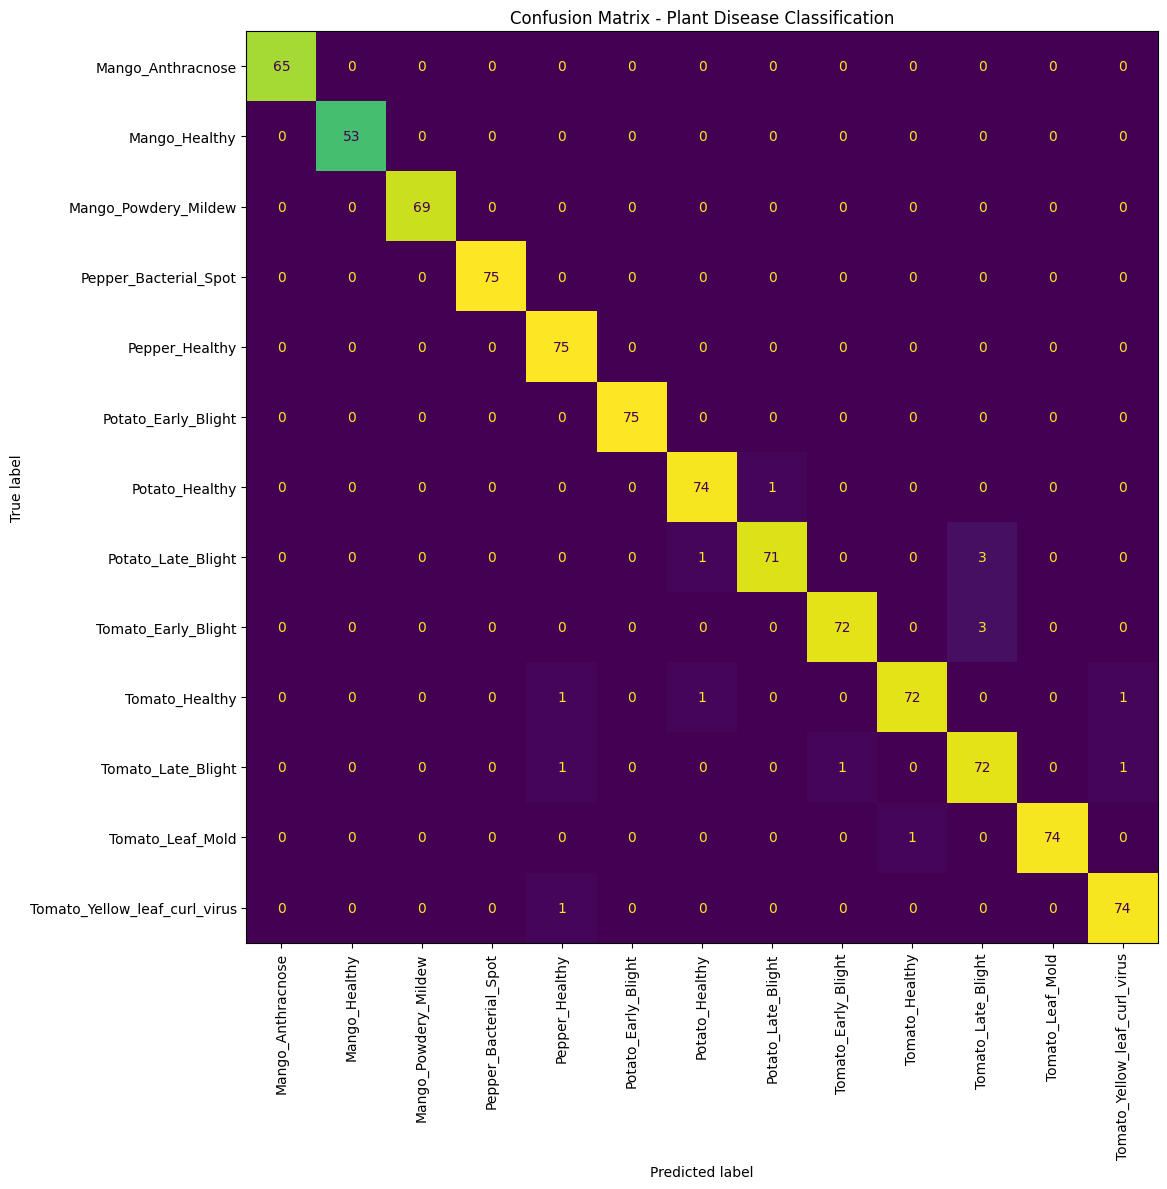

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model

# LOAD BEST MODEL
model = load_model("/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/models_second/best_stage1_model_tuned.keras")

# GET TRUE LABELS
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

# GET PREDICTIONS
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# CLASS NAMES
with open("models_second/class_names.txt", "r") as f:
    class_names = [line.strip() for line in f.readlines()]
print("Classes:", class_names)

# CLASSIFICATION REPORT
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("\nClassification Report:\n")
print(report)

# Optional: save report to a text file
with open("models_second/classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

# CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, values_format="d", colorbar=False)
plt.title("Confusion Matrix - Plant Disease Classification")
plt.tight_layout()
plt.show()

# Optional: save confusion matrix image
fig.savefig("models_second/confusion_matrix.png", dpi=300, bbox_inches="tight")

Found 937 files belonging to 13 classes.


2026-04-11 01:55:38.608911: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


59/59 ━━━━━━━━━━━━━━━━━━━━ 23s 382ms/step
Classes: ['Mango_Anthracnose', 'Mango_Healthy', 'Mango_Powdery_Mildew', 'Pepper_Bacterial_Spot', 'Pepper_Healthy', 'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Yellow_leaf_curl_virus']

Classification Report:

                               precision    recall  f1-score   support

            Mango_Anthracnose     1.0000    1.0000    1.0000        65
                Mango_Healthy     1.0000    1.0000    1.0000        53
         Mango_Powdery_Mildew     1.0000    1.0000    1.0000        69
        Pepper_Bacterial_Spot     1.0000    1.0000    1.0000        75
               Pepper_Healthy     0.9615    1.0000    0.9804        75
          Potato_Early_Blight     1.0000    1.0000    1.0000        75
               Potato_Healthy     0.9737    0.9867    0.9801        75
           Potato_Late_Blight     0.9861    0.9467    0.9660        75

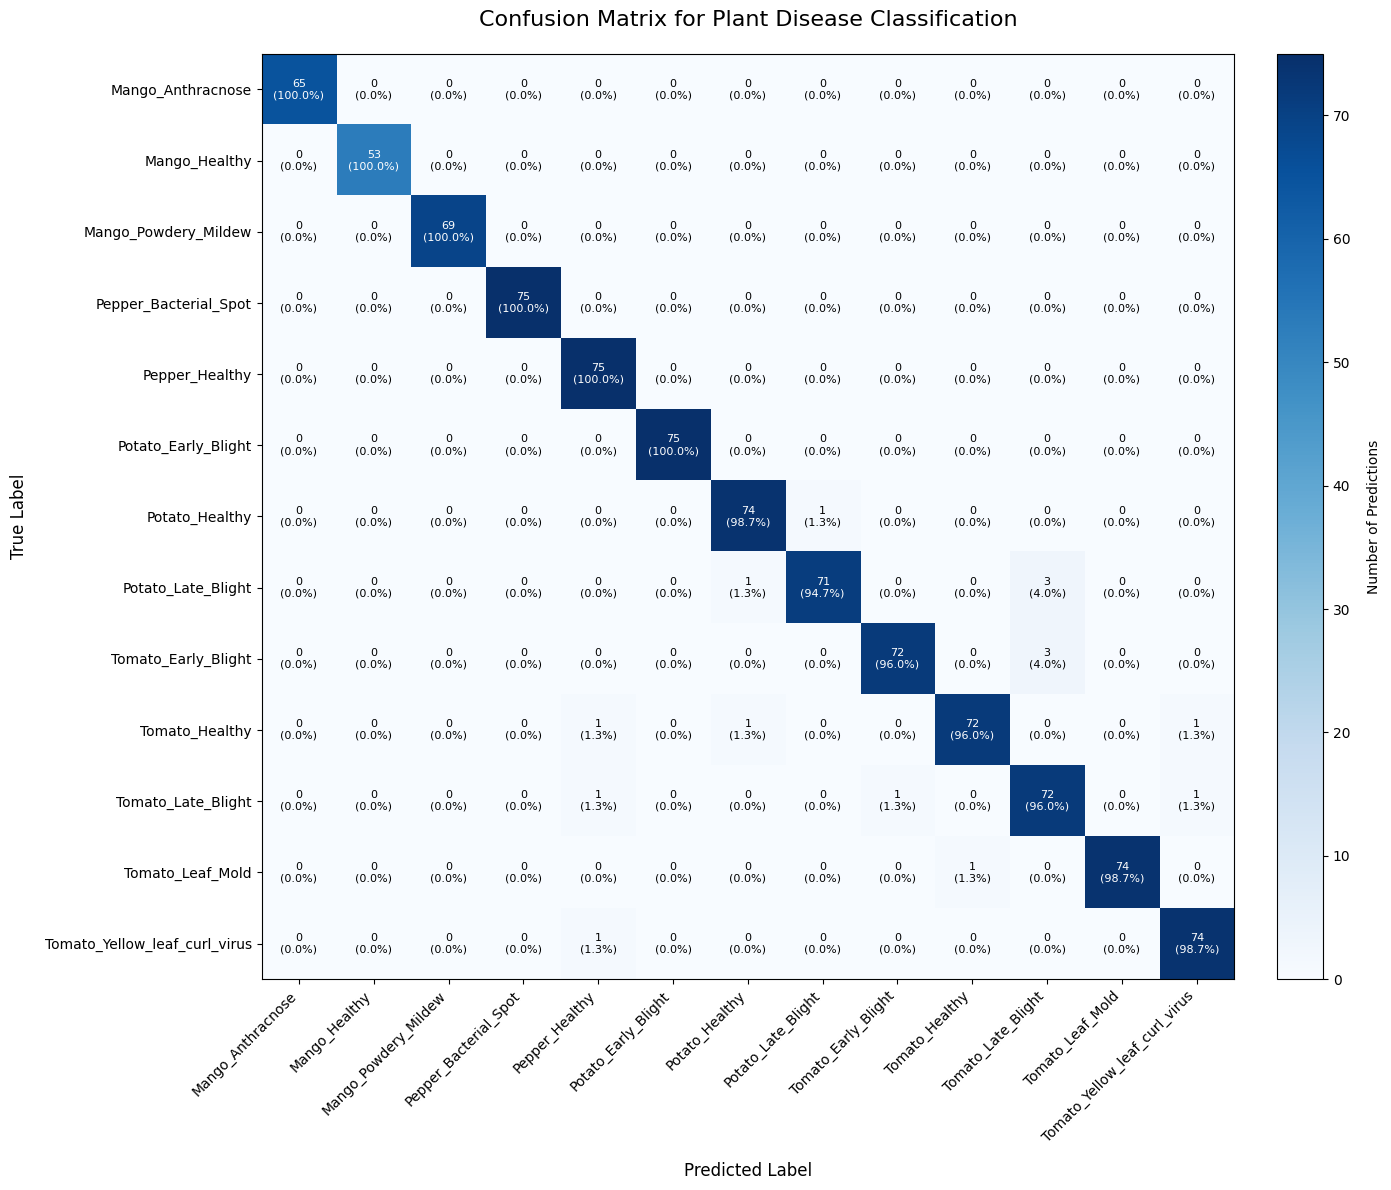

Professional confusion matrix saved to models_second/confusion_matrix_professional.png


In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model

# -----------------------------
# PATHS
# -----------------------------
test_dir = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset_second_split/test"
model_path = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/models_second/best_stage1_model_tuned.keras"
class_names_path = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/models_second/class_names_tuned.txt"

IMG_SIZE = (300, 300)
BATCH_SIZE = 16

# -----------------------------
# RECREATE TEST DATASET
# -----------------------------
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# -----------------------------
# LOAD MODEL
# -----------------------------
model = load_model(model_path)

# -----------------------------
# GET TRUE LABELS
# -----------------------------
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

# -----------------------------
# GET PREDICTIONS
# -----------------------------
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# -----------------------------
# LOAD CLASS NAMES
# -----------------------------
with open(class_names_path, "r", encoding="utf-8") as f:
    class_names = [line.strip() for line in f.readlines()]

print("Classes:", class_names)

# -----------------------------
# CLASSIFICATION REPORT
# -----------------------------
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("\nClassification Report:\n")
print(report)

with open("models_second/classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

# -----------------------------
# CONFUSION MATRIX
# -----------------------------
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))

# Change cmap here: "Blues", "Greys", "Purples", "BuGn"
im = ax.imshow(cm, cmap="Blues", aspect="auto")

ax.set_title("Confusion Matrix for Plant Disease Classification", fontsize=16, pad=20)
ax.set_xlabel("Predicted Label", fontsize=12, labelpad=12)
ax.set_ylabel("True Label", fontsize=12, labelpad=12)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(class_names, fontsize=10)

threshold = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count_text = f"{cm[i, j]}"
        percent_text = f"\n({cm_normalized[i, j]*100:.1f}%)"
        ax.text(
            j, i,
            count_text + percent_text,
            ha="center",
            va="center",
            fontsize=8,
            color="white" if cm[i, j] > threshold else "black"
        )

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel("Number of Predictions", rotation=90, labelpad=12)

plt.tight_layout()
fig.savefig("models_second/confusion_matrix_professional.png", dpi=400, bbox_inches="tight")
plt.show()

print("Professional confusion matrix saved to models_second/confusion_matrix_professional.png")

### Confusion Matrix for plant_disease_model_final_tuned

Found 937 files belonging to 13 classes.
Classes: ['Mango_Anthracnose', 'Mango_Healthy', 'Mango_Powdery_Mildew', 'Pepper_Bacterial_Spot', 'Pepper_Healthy', 'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Yellow_leaf_curl_virus']


2026-03-25 11:19:11.669782: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


59/59 ━━━━━━━━━━━━━━━━━━━━ 26s 424ms/step

Classification Report:

                               precision    recall  f1-score   support

            Mango_Anthracnose     0.9848    1.0000    0.9924        65
                Mango_Healthy     1.0000    1.0000    1.0000        53
         Mango_Powdery_Mildew     1.0000    1.0000    1.0000        69
        Pepper_Bacterial_Spot     0.9600    0.9600    0.9600        75
               Pepper_Healthy     0.9259    1.0000    0.9615        75
          Potato_Early_Blight     1.0000    0.8533    0.9209        75
               Potato_Healthy     0.8810    0.9867    0.9308        75
           Potato_Late_Blight     0.9844    0.8400    0.9065        75
          Tomato_Early_Blight     0.9351    0.9600    0.9474        75
               Tomato_Healthy     0.8675    0.9600    0.9114        75
           Tomato_Late_Blight     0.8889    0.9600    0.9231        75
             Tomato_Leaf_Mold     1.0000    0.8267    0.9051        75
Tomato_Ye

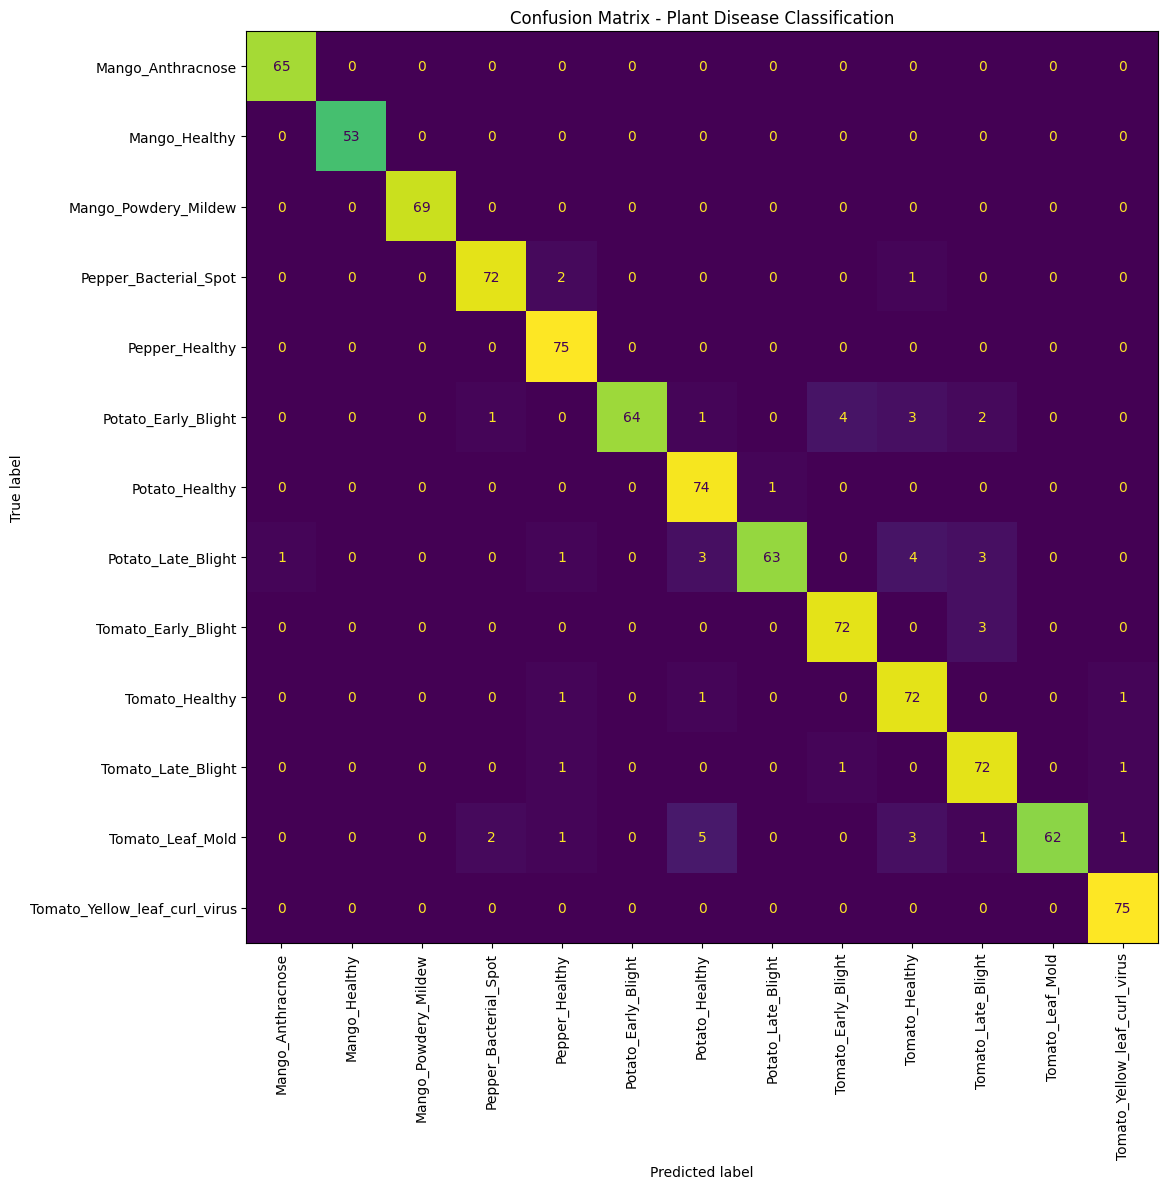

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model

# ============================================================
# PATHS
# ============================================================
MODEL_PATH = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/models_second/plant_disease_model_final_tuned.keras"
CLASS_NAMES_PATH = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/models_second/class_names_tuned.txt"
TEST_DIR = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset_split/test"

# IMPORTANT:
# match this to the model you are loading
IMG_SIZE = (300, 300)
BATCH_SIZE = 16

# ============================================================
# LOAD MODEL
# ============================================================
model = load_model(MODEL_PATH)

# ============================================================
# REBUILD TEST DATASET
# ============================================================
test_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE
test_ds = test_ds_raw.prefetch(AUTOTUNE)

# ============================================================
# LOAD CLASS NAMES
# ============================================================
with open(CLASS_NAMES_PATH, "r", encoding="utf-8") as f:
    class_names = [line.strip() for line in f.readlines()]

print("Classes:", class_names)

# ============================================================
# GET TRUE LABELS
# ============================================================
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

# ============================================================
# GET PREDICTIONS
# ============================================================
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# ============================================================
# CLASSIFICATION REPORT
# ============================================================
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("\nClassification Report:\n")
print(report)

with open("/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/models_second/classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

# ============================================================
# CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, values_format="d", colorbar=False)
plt.title("Confusion Matrix - Plant Disease Classification")
plt.tight_layout()
plt.show()

fig.savefig(
    "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/models_second/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

### Testing on mini_dataset for 2nd model

Loaded class names:
['Mango_Anthracnose', 'Mango_Healthy', 'Mango_Powdery_Mildew', 'Pepper_Bacterial_Spot', 'Pepper_Healthy', 'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Yellow_leaf_curl_virus']
Found 65 files belonging to 13 classes.

External dataset class names detected:
['Mango_Anthracnose', 'Mango_Healthy', 'Mango_Powdery_Mildew', 'Pepper_Bacterial_Spot', 'Pepper_Healthy', 'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Yellow_leaf_curl_virus']


2026-03-24 01:50:19.979510: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 562ms/step

Classification Report on External Test Dataset:

                               precision    recall  f1-score   support

            Mango_Anthracnose     1.0000    0.6000    0.7500         5
                Mango_Healthy     1.0000    0.4000    0.5714         5
         Mango_Powdery_Mildew     0.6667    0.4000    0.5000         5
        Pepper_Bacterial_Spot     0.7143    1.0000    0.8333         5
               Pepper_Healthy     0.7143    1.0000    0.8333         5
          Potato_Early_Blight     0.2500    0.2000    0.2222         5
               Potato_Healthy     0.2941    1.0000    0.4545         5
           Potato_Late_Blight     0.3333    0.2000    0.2500         5
          Tomato_Early_Blight     0.0000    0.0000    0.0000         5
               Tomato_Healthy     0.3333    0.6000    0.4286         5
           Tomato_Late_Blight     0.5000    0.4000    0.4444         5
             Tomato_Leaf_Mold     1.0000    0.2000    0.33

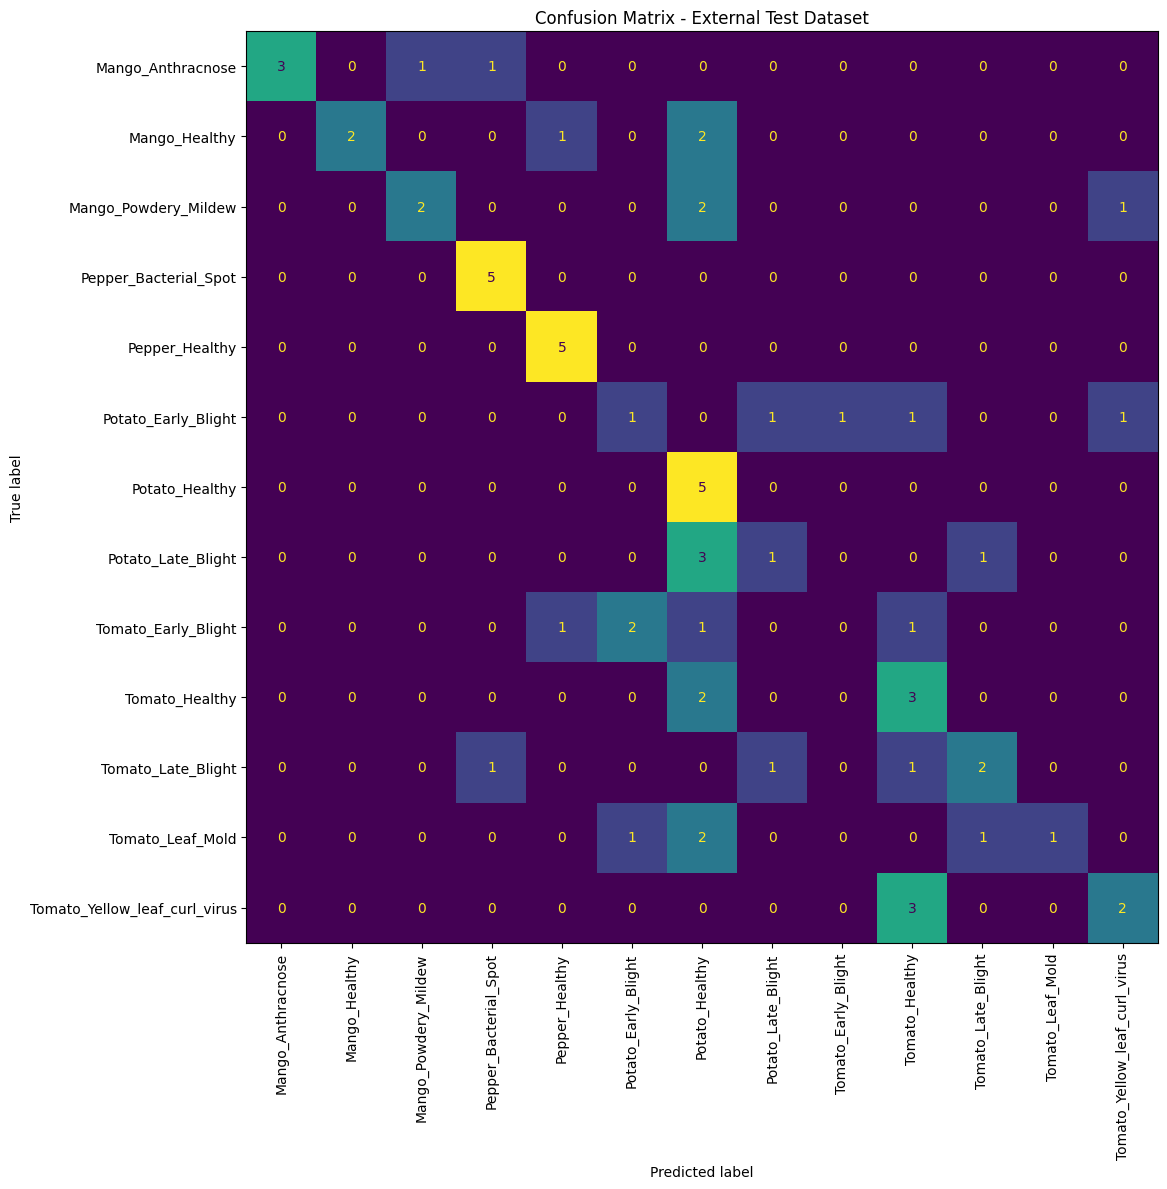


Per-image predictions:

File: /Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/mini_dataset/Mango_Anthracnose/Mango_Anthracnose_0001.png
True: Mango_Anthracnose
Pred: Mango_Powdery_Mildew
Confidence: 0.9755
--------------------------------------------------
File: /Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/mini_dataset/Mango_Anthracnose/Mango_Anthracnose_0002.png
True: Mango_Anthracnose
Pred: Mango_Anthracnose
Confidence: 1.0000
--------------------------------------------------
File: /Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/mini_dataset/Mango_Anthracnose/Mango_Anthracnose_0003.png
True: Mango_Anthracnose
Pred: Mango_Anthracnose
Confidence: 1.0000
--------------------------------------------------
File: /Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/mini_dataset/Mango_Anthracnose/Mango_Anthracnose_0004.png
True: Mango_Anthra

In [8]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model

# ============================================================
# PATHS
# ============================================================
MODEL_PATH = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/models_second/best_stage1_model_tuned.keras"
CLASS_NAMES_PATH = "models_second/class_names_tuned.txt"
EXTERNAL_TEST_DIR = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/mini_dataset"

# ============================================================
# SETTINGS
# ============================================================
#IMG_SIZE = (224, 224)
IMG_SIZE = (300, 300)  # if model was trained with 300x300
BATCH_SIZE = 16

# ============================================================
# LOAD MODEL
# ============================================================
model = load_model(MODEL_PATH)

# ============================================================
# LOAD SAVED CLASS NAMES
# ============================================================
with open(CLASS_NAMES_PATH, "r", encoding="utf-8") as f:
    class_names = [line.strip() for line in f.readlines()]

print("Loaded class names:")
print(class_names)

# ============================================================
# LOAD EXTERNAL DATASET
# ============================================================
external_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    EXTERNAL_TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nExternal dataset class names detected:")
print(external_ds_raw.class_names)

AUTOTUNE = tf.data.AUTOTUNE
external_ds = external_ds_raw.prefetch(buffer_size=AUTOTUNE)

# ============================================================
# TRUE LABELS
# ============================================================
y_true = np.concatenate([y.numpy() for _, y in external_ds], axis=0)

# ============================================================
# PREDICTIONS
# ============================================================
y_pred_probs = model.predict(external_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# ============================================================
# CLASSIFICATION REPORT
# ============================================================
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("\nClassification Report on External Test Dataset:\n")
print(report)

# ============================================================
# CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, values_format="d", colorbar=False)
plt.title("Confusion Matrix - External Test Dataset")
plt.tight_layout()
plt.show()

# ============================================================
# PER-IMAGE PREDICTIONS
# ============================================================
file_paths = []
for class_dir in sorted(Path(EXTERNAL_TEST_DIR).iterdir()):
    if class_dir.is_dir():
        for img_file in sorted(class_dir.iterdir()):
            if img_file.is_file():
                file_paths.append(str(img_file))

print("\nPer-image predictions:\n")
for i, path in enumerate(file_paths):
    true_label = class_names[y_true[i]]
    pred_label = class_names[y_pred[i]]
    confidence = np.max(y_pred_probs[i])

    print(f"File: {path}")
    print(f"True: {true_label}")
    print(f"Pred: {pred_label}")
    print(f"Confidence: {confidence:.4f}")
    print("-" * 50)

### Testing on new unseen images dataset (15 images per class)

Loaded class names:
['Mango_Anthracnose', 'Mango_Healthy', 'Mango_Powdery_Mildew', 'Pepper_Bacterial_Spot', 'Pepper_Healthy', 'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Yellow_leaf_curl_virus']
Found 195 files belonging to 13 classes.

External dataset class names detected:
['Mango_Anthracnose', 'Mango_Healthy', 'Mango_Powdery_Mildew', 'Pepper_Bacterial_Spot', 'Pepper_Healthy', 'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Yellow_Leaf_Curl_Virus']


2026-03-29 00:39:18.488572: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 419ms/step

Classification Report on External Test Dataset:

                               precision    recall  f1-score   support

            Mango_Anthracnose     1.0000    1.0000    1.0000        15
                Mango_Healthy     1.0000    1.0000    1.0000        15
         Mango_Powdery_Mildew     1.0000    1.0000    1.0000        15
        Pepper_Bacterial_Spot     1.0000    1.0000    1.0000        15
               Pepper_Healthy     1.0000    1.0000    1.0000        15
          Potato_Early_Blight     1.0000    0.9333    0.9655        15
               Potato_Healthy     1.0000    0.9333    0.9655        15
           Potato_Late_Blight     0.8824    1.0000    0.9375        15
          Tomato_Early_Blight     1.0000    1.0000    1.0000        15
               Tomato_Healthy     1.0000    1.0000    1.0000        15
           Tomato_Late_Blight     1.0000    1.0000    1.0000        15
             Tomato_Leaf_Mold     1.0000    1.0000    1.

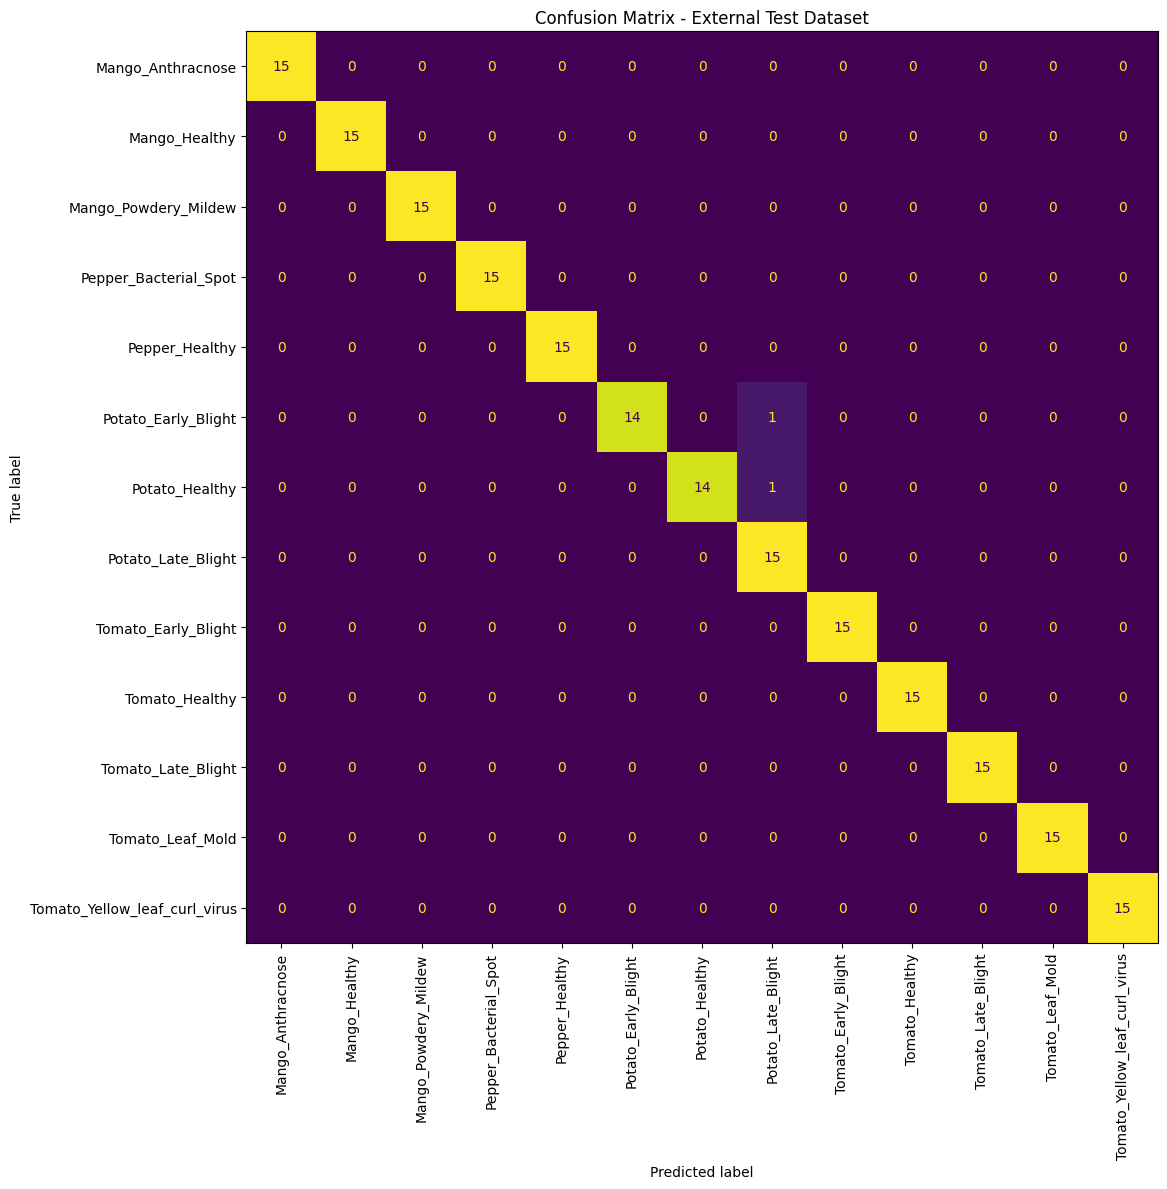


Per-image predictions:

File: /Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/unseen_test_dataset_final/Mango_Anthracnose/Mango_Anthracnose_0001.jpg
True: Mango_Anthracnose
Pred: Mango_Anthracnose
Confidence: 1.0000
--------------------------------------------------
File: /Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/unseen_test_dataset_final/Mango_Anthracnose/Mango_Anthracnose_0002.jpg
True: Mango_Anthracnose
Pred: Mango_Anthracnose
Confidence: 1.0000
--------------------------------------------------
File: /Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/unseen_test_dataset_final/Mango_Anthracnose/Mango_Anthracnose_0003.jpg
True: Mango_Anthracnose
Pred: Mango_Anthracnose
Confidence: 1.0000
--------------------------------------------------
File: /Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/unseen_test_dataset_final/Mango_Anthracn

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model

# ============================================================
# PATHS
# ============================================================
MODEL_PATH = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/models_second/best_stage1_model_tuned.keras"
CLASS_NAMES_PATH = "models_second/class_names_tuned.txt"
EXTERNAL_TEST_DIR = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/unseen_test_dataset_final"

# ============================================================
# SETTINGS
# ============================================================
#IMG_SIZE = (224, 224)
IMG_SIZE = (300, 300)  # if model was trained with 300x300
BATCH_SIZE = 16

# ============================================================
# LOAD MODEL
# ============================================================
model = load_model(MODEL_PATH)

# ============================================================
# LOAD SAVED CLASS NAMES
# ============================================================
with open(CLASS_NAMES_PATH, "r", encoding="utf-8") as f:
    class_names = [line.strip() for line in f.readlines()]

print("Loaded class names:")
print(class_names)

# ============================================================
# LOAD EXTERNAL DATASET
# ============================================================
external_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    EXTERNAL_TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nExternal dataset class names detected:")
print(external_ds_raw.class_names)

AUTOTUNE = tf.data.AUTOTUNE
external_ds = external_ds_raw.prefetch(buffer_size=AUTOTUNE)

# ============================================================
# TRUE LABELS
# ============================================================
y_true = np.concatenate([y.numpy() for _, y in external_ds], axis=0)

# ============================================================
# PREDICTIONS
# ============================================================
y_pred_probs = model.predict(external_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# ============================================================
# CLASSIFICATION REPORT
# ============================================================
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("\nClassification Report on External Test Dataset:\n")
print(report)

# ============================================================
# CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, values_format="d", colorbar=False)
plt.title("Confusion Matrix - External Test Dataset")
plt.tight_layout()
plt.show()

# ============================================================
# PER-IMAGE PREDICTIONS
# ============================================================
file_paths = []
for class_dir in sorted(Path(EXTERNAL_TEST_DIR).iterdir()):
    if class_dir.is_dir():
        for img_file in sorted(class_dir.iterdir()):
            if img_file.is_file():
                file_paths.append(str(img_file))

print("\nPer-image predictions:\n")
for i, path in enumerate(file_paths):
    true_label = class_names[y_true[i]]
    pred_label = class_names[y_pred[i]]
    confidence = np.max(y_pred_probs[i])

    print(f"File: {path}")
    print(f"True: {true_label}")
    print(f"Pred: {pred_label}")
    print(f"Confidence: {confidence:.4f}")
    print("-" * 50)

### Training with segmentation included

In [9]:
import os
import cv2
import numpy as np
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# PATHS
train_dir = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset_split/train"
val_dir = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset_split/val"
test_dir = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset_split/test"

os.makedirs("models_third", exist_ok=True)

# SETTINGS
IMG_SIZE = (300, 300)
BATCH_SIZE = 16
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

# LOAD DATASETS
train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

test_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds_raw.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

# COMPUTE CLASS WEIGHTS
y_train_all = np.concatenate([y.numpy() for _, y in train_ds_raw], axis=0)
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_all),
    y=y_train_all
)
class_weights = dict(enumerate(class_weights_arr))
print("Class weights:", class_weights)

# PREPROCESSING: GrabCut + CLAHE
def preprocess_leaf_np(image):
    img = image.astype(np.uint8)
    h, w = img.shape[:2]

    mask = np.zeros((h, w), np.uint8)
    rect = (int(w * 0.08), int(h * 0.08), int(w * 0.84), int(h * 0.84))
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)

    try:
        cv2.grabCut(img, mask, rect, bgd_model, fgd_model, 3, cv2.GC_INIT_WITH_RECT)
        mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8")
        segmented = img * mask2[:, :, np.newaxis]

        coords = cv2.findNonZero(mask2)
        if coords is not None:
            x, y, w2, h2 = cv2.boundingRect(coords)
            segmented = segmented[y:y+h2, x:x+w2]
        else:
            segmented = img
    except Exception:
        segmented = img

    segmented = cv2.resize(segmented, IMG_SIZE)

    lab = cv2.cvtColor(segmented, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l2 = clahe.apply(l)
    enhanced = cv2.merge((l2, a, b))
    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2RGB)

    return enhanced.astype(np.float32)

def preprocess_batch(images, labels):
    processed_images = tf.map_fn(
        lambda img: tf.numpy_function(preprocess_leaf_np, [img], tf.float32),
        images,
        fn_output_signature=tf.TensorSpec(
            shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
            dtype=tf.float32
        )
    )
    processed_images.set_shape((None, IMG_SIZE[0], IMG_SIZE[1], 3))
    return processed_images, labels

# APPLY PREPROCESSING
train_ds = train_ds_raw.map(preprocess_batch, num_parallel_calls=AUTOTUNE)
val_ds = val_ds_raw.map(preprocess_batch, num_parallel_calls=AUTOTUNE)
test_ds = test_ds_raw.map(preprocess_batch, num_parallel_calls=AUTOTUNE)

# LIGHT AUGMENTATION
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.04),
    layers.RandomZoom(0.04),
])

# PERFORMANCE OPTIMISATION
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

# BASE MODEL
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(300, 300, 3)
)
base_model.trainable = False

# BUILD MODEL
inputs = layers.Input(shape=(300, 300, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.35)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

# STAGE 1
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=8e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_stage1 = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="models_third/best_stage1_model_seg.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("\nStarting Stage 1 training...")
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=callbacks_stage1,
    class_weight=class_weights
)

# LOAD BEST STAGE 1 WEIGHTS
model.load_weights("models_third/best_stage1_model_seg.keras")

# STAGE 2: FINE-TUNING
base_model.trainable = True

fine_tune_at = int(len(base_model.layers) * 0.92)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_stage2 = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="models_third/best_finetuned_model_seg.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("\nStarting Stage 2 fine-tuning...")
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=callbacks_stage2,
    class_weight=class_weights
)

# EVALUATE BEST STAGE 1
print("\nEvaluating best Stage 1 model...")
stage1_best = tf.keras.models.load_model("models_third/best_stage1_model_seg.keras", compile=False)
stage1_best.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
stage1_loss, stage1_acc = stage1_best.evaluate(test_ds)
print(f"Best Stage 1 - Test Loss: {stage1_loss:.4f}")
print(f"Best Stage 1 - Test Accuracy: {stage1_acc:.4f}")

# EVALUATE BEST STAGE 2
print("\nEvaluating best fine-tuned model...")
stage2_best = tf.keras.models.load_model("models_third/best_finetuned_model_seg.keras", compile=False)
stage2_best.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
stage2_loss, stage2_acc = stage2_best.evaluate(test_ds)
print(f"Best Fine-Tuned - Test Loss: {stage2_loss:.4f}")
print(f"Best Fine-Tuned - Test Accuracy: {stage2_acc:.4f}")

# SAVE FINAL CHOSEN MODEL
if stage2_acc >= stage1_acc:
    final_model = stage2_best
    print("\nUsing fine-tuned model as final model.")
else:
    final_model = stage1_best
    print("\nUsing Stage 1 model as final model.")

final_model_path = "models_third/plant_disease_model_final_seg.keras"
final_model.save(final_model_path)
print(f"Final model saved to: {final_model_path}")

# SAVE CLASS NAMES
class_names_path = "models_third/class_names_seg.txt"
with open(class_names_path, "w", encoding="utf-8") as f:
    for name in class_names:
        f.write(name + "\n")

print(f"Class names saved to: {class_names_path}")

Found 4357 files belonging to 13 classes.
Found 936 files belonging to 13 classes.
Found 937 files belonging to 13 classes.
Classes: ['Mango_Anthracnose', 'Mango_Healthy', 'Mango_Powdery_Mildew', 'Pepper_Bacterial_Spot', 'Pepper_Healthy', 'Potato_Early_blight', 'Potato_Healthy', 'Potato_Late_blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Yellow_leaf_curl_virus']
Number of classes: 13
Class weights: {0: np.float64(1.1134679274214159), 1: np.float64(1.3568981625661787), 2: np.float64(1.0572676534821646), 3: np.float64(0.9603262067445448), 4: np.float64(0.9603262067445448), 5: np.float64(0.9603262067445448), 6: np.float64(0.9603262067445448), 7: np.float64(0.9603262067445448), 8: np.float64(0.9575824175824176), 9: np.float64(0.9603262067445448), 10: np.float64(0.9575824175824176), 11: np.float64(0.9603262067445448), 12: np.float64(0.9603262067445448)}

Starting Stage 1 training...
Epoch 1/12
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - acc

KeyboardInterrupt: 

### Confusion Matrix for 3rd Training

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model

# LOAD BEST MODEL
model = load_model("/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/models_second/best_stage1_model_tuned.keras")

# GET TRUE LABELS
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

# GET PREDICTIONS
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# CLASS NAMES
with open("models_second/class_names.txt", "r") as f:
    class_names = [line.strip() for line in f.readlines()]
print("Classes:", class_names)

# CLASSIFICATION REPORT
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("\nClassification Report:\n")
print(report)

# Optional: save report to a text file
with open("models_second/classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

# CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, values_format="d", colorbar=False)
plt.title("Confusion Matrix - Plant Disease Classification")
plt.tight_layout()
plt.show()

# Optional: save confusion matrix image
fig.savefig("models_second/confusion_matrix.png", dpi=300, bbox_inches="tight")

## Implementation of disease severity module

#### First step is to predict the class of an image inserted by the user

In [6]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model

# CONFIG
MODEL_PATH = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/models_second/best_stage1_model_tuned.keras"
CLASS_NAMES_PATH = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/models_second/class_names_tuned.txt"
IMAGE_PATH = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/mini_dataset/Mango_Anthracnose/Mango_Anthracnose_0005.png"

IMG_SIZE = (300, 300)

# LOAD MODEL + CLASS NAMES
model = load_model(MODEL_PATH)

with open(CLASS_NAMES_PATH, "r", encoding="utf-8") as f:
    class_names = [line.strip() for line in f.readlines()]

# LOAD IMAGE
def load_and_prepare_image(image_path, img_size=(300, 300)):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise ValueError(f"Could not read image: {image_path}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    original = img_rgb.copy()

    resized = cv2.resize(img_rgb, img_size)
    img_array = resized.astype(np.float32)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

    return original, resized, img_array

original_img, resized_img, img_array = load_and_prepare_image(IMAGE_PATH, IMG_SIZE)

# PREDICT
pred_probs = model.predict(img_array)[0]
pred_idx = np.argmax(pred_probs)
pred_class = class_names[pred_idx]
confidence = pred_probs[pred_idx]

print("Predicted class:", pred_class)
print("Confidence:", f"{confidence:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 996ms/step
Predicted class: Mango_Anthracnose
Confidence: 1.0000


#### Apply Grad-CAM heatmap on the image inserted by the user

In [2]:
from tensorflow.keras.models import load_model

MODEL_PATH = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/models_second/best_stage1_model_tuned.keras"

model = load_model(MODEL_PATH)

for layer in model.layers:
    print(layer.name)

input_layer_4
sequential_1
efficientnetb0
global_average_pooling2d_1
batch_normalization_1
dense_2
dropout_1
dense_3


In [3]:
from tensorflow.keras.models import load_model

MODEL_PATH = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/models_second/best_stage1_model_tuned.keras"

model = load_model(MODEL_PATH)

print("Top-level model layers:")
for layer in model.layers:
    print(layer.name, type(layer))

print("\nBackbone layers:")
for layer in model.layers:
    if hasattr(layer, "layers"):
        print(f"\nSubmodel: {layer.name}")
        for sublayer in layer.layers:
            print(sublayer.name)

Top-level model layers:
input_layer_4 <class 'keras.src.layers.core.input_layer.InputLayer'>
sequential_1 <class 'keras.src.models.sequential.Sequential'>
efficientnetb0 <class 'keras.src.models.functional.Functional'>
global_average_pooling2d_1 <class 'keras.src.layers.pooling.global_average_pooling2d.GlobalAveragePooling2D'>
batch_normalization_1 <class 'keras.src.layers.normalization.batch_normalization.BatchNormalization'>
dense_2 <class 'keras.src.layers.core.dense.Dense'>
dropout_1 <class 'keras.src.layers.regularization.dropout.Dropout'>
dense_3 <class 'keras.src.layers.core.dense.Dense'>

Backbone layers:

Submodel: sequential_1
random_flip_1
random_rotation_1
random_zoom_1

Submodel: efficientnetb0
input_layer_3
rescaling_2
normalization_1
rescaling_3
stem_conv_pad
stem_conv
stem_bn
stem_activation
block1a_dwconv
block1a_bn
block1a_activation
block1a_se_squeeze
block1a_se_reshape
block1a_se_reduce
block1a_se_expand
block1a_se_excite
block1a_project_conv
block1a_project_bn
bloc

Predicted class: Mango_Anthracnose
Confidence: 1.0000


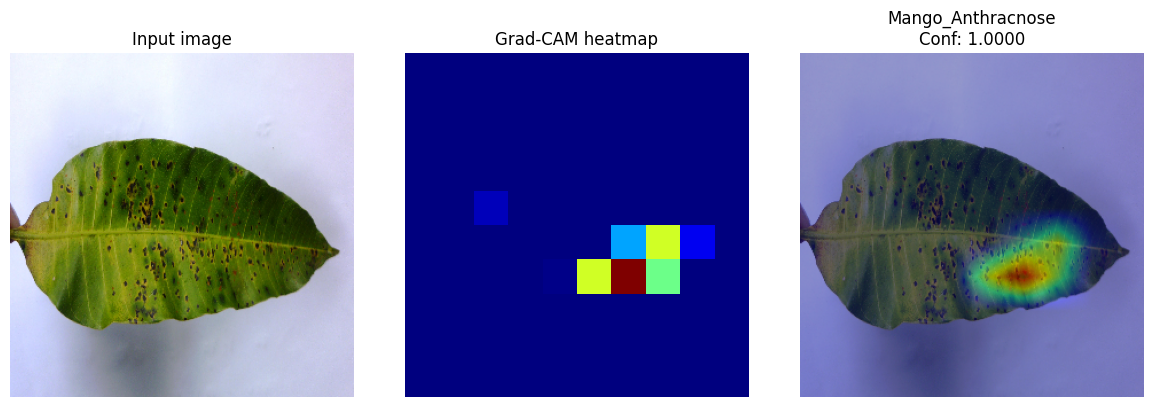

In [7]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# ============================================================
# CONFIG
# ============================================================
MODEL_PATH = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/models_second/best_stage1_model_tuned.keras"
CLASS_NAMES_PATH = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/models_second/class_names_tuned.txt"
IMAGE_PATH = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/mini_dataset/Mango_Anthracnose/Mango_Anthracnose_0005.png"

IMG_SIZE = (300, 300)
BASE_MODEL_NAME = "efficientnetb0"
LAST_CONV_LAYER_NAME = "top_conv"

# ============================================================
# LOAD MODEL + CLASS NAMES
# ============================================================
model = load_model(MODEL_PATH)

with open(CLASS_NAMES_PATH, "r", encoding="utf-8") as f:
    class_names = [line.strip() for line in f.readlines()]

# ============================================================
# LOAD IMAGE
# ============================================================
def load_and_prepare_image(image_path, img_size=(300, 300)):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise ValueError(f"Could not read image: {image_path}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    original = img_rgb.copy()

    resized = cv2.resize(img_rgb, img_size)
    img_array = resized.astype(np.float32)
    img_array = np.expand_dims(img_array, axis=0)

    return original, resized, img_array

original_img, resized_img, img_array = load_and_prepare_image(IMAGE_PATH, IMG_SIZE)

# ============================================================
# PREDICT
# ============================================================
pred_probs = model.predict(img_array, verbose=0)[0]
pred_idx = np.argmax(pred_probs)
pred_class = class_names[pred_idx]
confidence = pred_probs[pred_idx]

print("Predicted class:", pred_class)
print("Confidence:", f"{confidence:.4f}")

# ============================================================
# FIXED GRAD-CAM
# ============================================================
def make_gradcam_heatmap(img_array, model, base_model_name="efficientnetb0", last_conv_layer_name="top_conv", pred_index=None):
    # Top-level layers
    aug_layer = model.get_layer("sequential_1")
    base_model = model.get_layer(base_model_name)

    # Build a model from input -> last conv feature maps
    last_conv_layer = base_model.get_layer(last_conv_layer_name)
    conv_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=last_conv_layer.output
    )

    # Build classifier head manually: from top_conv output to final prediction
    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])

    x = classifier_input

    # Continue through remaining EfficientNet layers after top_conv
    take = False
    for layer in base_model.layers:
        if layer.name == last_conv_layer_name:
            take = True
            continue
        if take:
            x = layer(x)

    # Then continue through top-level classifier head after efficientnetb0
    passed_backbone = False
    for layer in model.layers:
        if layer.name == base_model_name:
            passed_backbone = True
            continue
        if passed_backbone:
            x = layer(x)

    classifier_model = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        # Recreate the same preprocessing path as the original model
        augmented = aug_layer(img_array, training=False)
        preprocessed = tf.keras.applications.efficientnet.preprocess_input(augmented)

        conv_outputs = conv_model(preprocessed)
        tape.watch(conv_outputs)

        predictions = classifier_model(conv_outputs)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)
    if max_val > 0:
        heatmap /= max_val

    return heatmap.numpy()

heatmap = make_gradcam_heatmap(
    img_array,
    model,
    BASE_MODEL_NAME,
    LAST_CONV_LAYER_NAME,
    pred_idx
)

# ============================================================
# OVERLAY FUNCTION
# ============================================================
def overlay_gradcam_on_image(image_rgb, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (image_rgb.shape[1], image_rgb.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(image_rgb, 1 - alpha, heatmap_color, alpha, 0)
    return overlay

overlay = overlay_gradcam_on_image(resized_img, heatmap)

# ============================================================
# DISPLAY
# ============================================================
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(resized_img)
plt.title("Input image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(f"{pred_class}\nConf: {confidence:.4f}")
plt.axis("off")

plt.tight_layout()
plt.show()

#### Display the Grad-CAM overlay

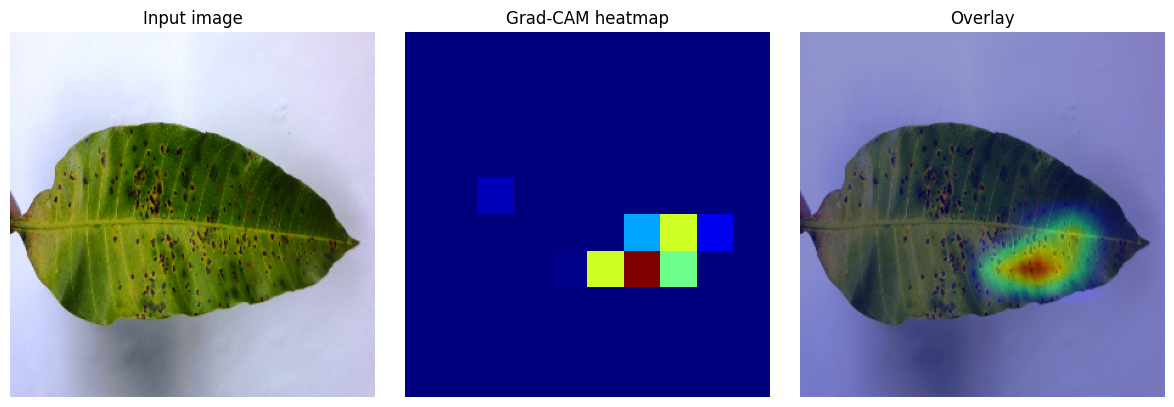

In [8]:
import matplotlib.pyplot as plt

def overlay_gradcam_on_image(image_rgb, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (image_rgb.shape[1], image_rgb.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(image_rgb, 1 - alpha, heatmap_color, alpha, 0)
    return overlay

overlay = overlay_gradcam_on_image(resized_img, heatmap)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(resized_img)
plt.title("Input image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap, cmap="jet")
plt.title("Grad-CAM heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

#### Segment the leaf area

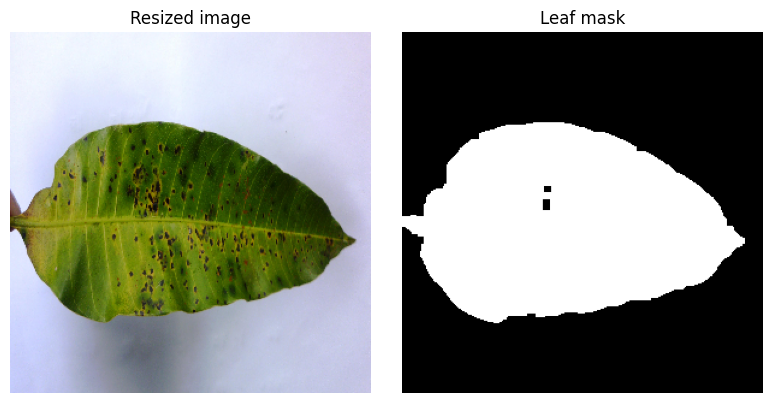

In [9]:
def segment_leaf_mask(image_rgb):
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)

    # Green range — may need adjustment
    lower_green = np.array([20, 30, 20])
    upper_green = np.array([100, 255, 255])

    mask = cv2.inRange(hsv, lower_green, upper_green)

    # Clean mask
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    return mask

leaf_mask = segment_leaf_mask(resized_img)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(resized_img)
plt.title("Resized image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(leaf_mask, cmap="gray")
plt.title("Leaf mask")
plt.axis("off")
plt.tight_layout()
plt.show()

#### Convert Grad-CAM to affected-area mask

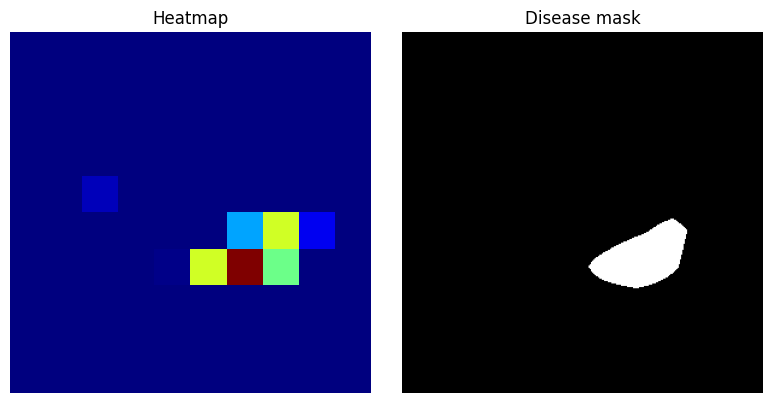

In [10]:
def create_disease_mask_from_heatmap(heatmap, image_shape, threshold=0.4):
    heatmap_resized = cv2.resize(heatmap, (image_shape[1], image_shape[0]))
    disease_mask = (heatmap_resized >= threshold).astype(np.uint8) * 255
    return disease_mask

disease_mask = create_disease_mask_from_heatmap(heatmap, resized_img.shape, threshold=0.4)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(heatmap, cmap="jet")
plt.title("Heatmap")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(disease_mask, cmap="gray")
plt.title("Disease mask")
plt.axis("off")
plt.tight_layout()
plt.show()

#### Combine disease mask with leaf mask

In [11]:
def compute_severity(leaf_mask, disease_mask):
    # Convert masks to binary
    leaf_binary = (leaf_mask > 0).astype(np.uint8)
    disease_binary = (disease_mask > 0).astype(np.uint8)

    affected_mask = leaf_binary * disease_binary

    leaf_pixels = np.sum(leaf_binary)
    affected_pixels = np.sum(affected_mask)

    if leaf_pixels == 0:
        severity_percent = 0.0
    else:
        severity_percent = (affected_pixels / leaf_pixels) * 100

    return affected_mask, leaf_pixels, affected_pixels, severity_percent

affected_mask, leaf_pixels, affected_pixels, severity_percent = compute_severity(
    leaf_mask, disease_mask
)

print("Leaf pixels:", leaf_pixels)
print("Affected pixels:", affected_pixels)
print("Severity percent:", f"{severity_percent:.2f}%")

Leaf pixels: 32455
Affected pixels: 2826
Severity percent: 8.71%


### Severity Grade

In [12]:
def severity_label_from_percent(severity_percent):
    if severity_percent < 15:
        return "Mild"
    elif severity_percent < 35:
        return "Moderate"
    else:
        return "Severe"

severity_label = severity_label_from_percent(severity_percent)

print("Severity label:", severity_label)

Severity label: Mild


#### Visualise final affected area

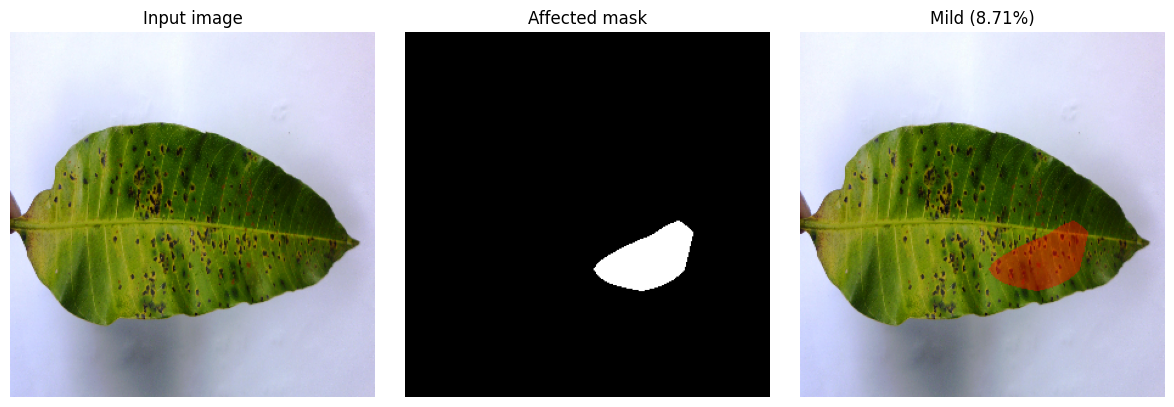

In [13]:
def overlay_mask_on_image(image_rgb, mask, color=(255, 0, 0), alpha=0.35):
    overlay = image_rgb.copy()
    mask_bool = mask > 0

    color_layer = np.zeros_like(image_rgb)
    color_layer[:, :] = color

    overlay[mask_bool] = cv2.addWeighted(
        image_rgb[mask_bool], 1 - alpha,
        color_layer[mask_bool], alpha,
        0
    )
    return overlay

affected_overlay = overlay_mask_on_image(resized_img, affected_mask * 255, color=(255, 0, 0), alpha=0.4)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(resized_img)
plt.title("Input image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(affected_mask, cmap="gray")
plt.title("Affected mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(affected_overlay)
plt.title(f"{severity_label} ({severity_percent:.2f}%)")
plt.axis("off")

plt.tight_layout()
plt.show()

#### Final combined function

Loaded classes: ['Mango_Anthracnose', 'Mango_Healthy', 'Mango_Powdery_Mildew', 'Pepper_Bacterial_Spot', 'Pepper_Healthy', 'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Yellow_leaf_curl_virus']
Predicted class: Mango_Powdery_Mildew
Confidence: 1.0000
Leaf pixels: 29855
Affected pixels: 19324
Severity percent: 64.73%
Severity label: Severe


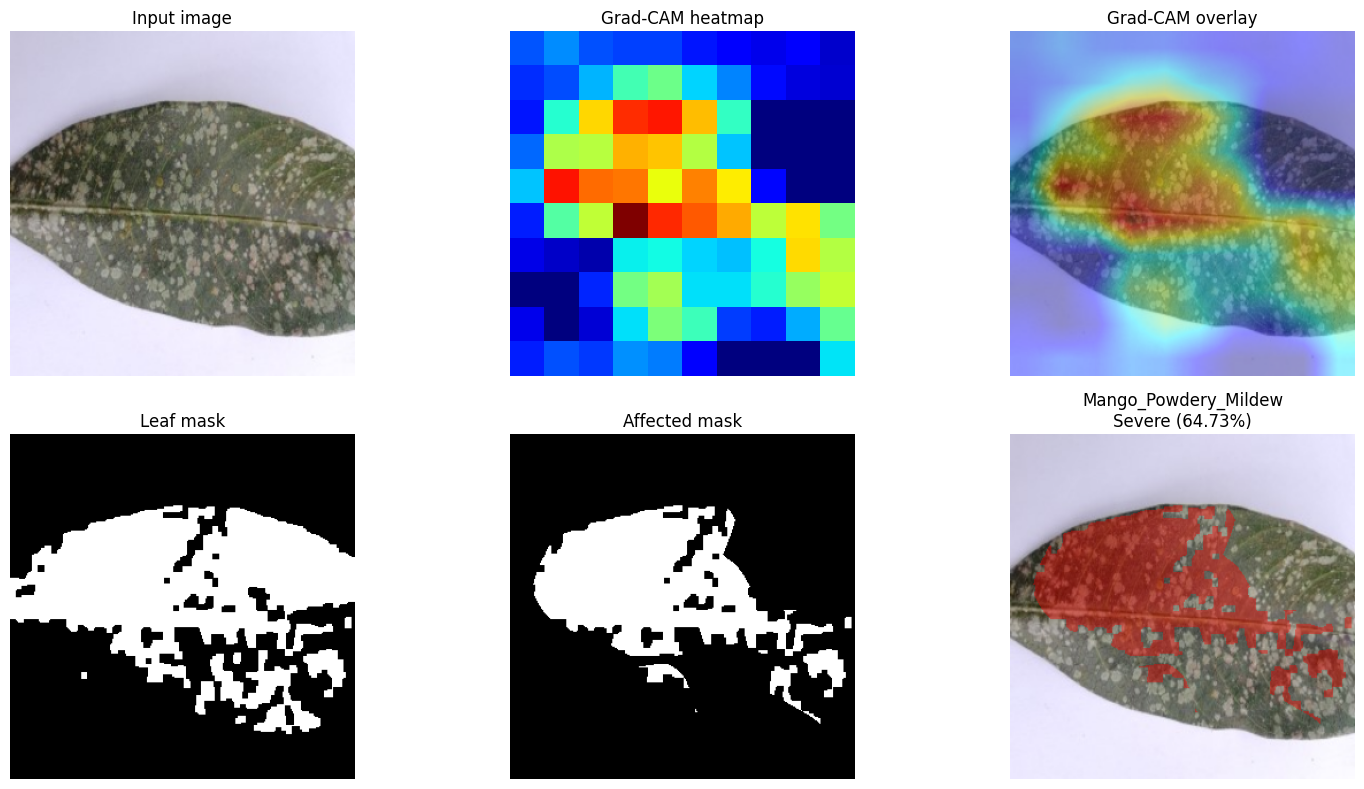

In [13]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# ============================================================
# CONFIG
# ============================================================
MODEL_PATH = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/models_second/best_stage1_model_tuned.keras"
CLASS_NAMES_PATH = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/models_second/class_names_tuned.txt"
IMAGE_PATH = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/unseen_test_dataset_final/Mango_Powdery_Mildew/Mango_Powdery_Mildew_0006.jpg"


IMG_SIZE = (300, 300)
BASE_MODEL_NAME = "efficientnetb0"
LAST_CONV_LAYER_NAME = "top_conv"

# ============================================================
# LOAD MODEL + CLASS NAMES
# ============================================================
model = load_model(MODEL_PATH)

with open(CLASS_NAMES_PATH, "r", encoding="utf-8") as f:
    class_names = [line.strip() for line in f.readlines()]

print("Loaded classes:", class_names)

# ============================================================
# LOAD IMAGE
# ============================================================
def load_and_prepare_image(image_path, img_size=(300, 300)):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise ValueError(f"Could not read image: {image_path}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    original = img_rgb.copy()

    resized = cv2.resize(img_rgb, img_size)
    img_array = resized.astype(np.float32)
    img_array = np.expand_dims(img_array, axis=0)

    return original, resized, img_array

# ============================================================
# PREDICT
# ============================================================
def predict_disease(img_array, model, class_names):
    pred_probs = model.predict(img_array, verbose=0)[0]
    pred_idx = np.argmax(pred_probs)
    pred_class = class_names[pred_idx]
    confidence = pred_probs[pred_idx]
    return pred_probs, pred_idx, pred_class, confidence

# ============================================================
# FIXED GRAD-CAM
# ============================================================
def make_gradcam_heatmap(
    img_array,
    model,
    base_model_name="efficientnetb0",
    last_conv_layer_name="top_conv",
    pred_index=None
):
    # top-level augmentation layer
    aug_layer = model.get_layer("sequential_1")

    # backbone
    base_model = model.get_layer(base_model_name)
    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    # model from backbone input -> last conv output
    conv_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=last_conv_layer.output
    )

    # classifier head from last conv output -> final prediction
    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input

    # remaining backbone layers after top_conv
    take = False
    for layer in base_model.layers:
        if layer.name == last_conv_layer_name:
            take = True
            continue
        if take:
            x = layer(x)

    # remaining top-level layers after efficientnetb0
    passed_backbone = False
    for layer in model.layers:
        if layer.name == base_model_name:
            passed_backbone = True
            continue
        if passed_backbone:
            x = layer(x)

    classifier_model = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        # same path as original model
        augmented = aug_layer(img_array, training=False)
        preprocessed = tf.keras.applications.efficientnet.preprocess_input(augmented)

        conv_outputs = conv_model(preprocessed)
        tape.watch(conv_outputs)

        predictions = classifier_model(conv_outputs)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)
    if max_val > 0:
        heatmap /= max_val

    return heatmap.numpy()

# ============================================================
# LEAF SEGMENTATION
# ============================================================
def segment_leaf_mask(image_rgb):
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)

    # adjust if needed
    lower_green = np.array([20, 30, 20])
    upper_green = np.array([100, 255, 255])

    mask = cv2.inRange(hsv, lower_green, upper_green)

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    return mask

# ============================================================
# HEATMAP -> DISEASE MASK
# ============================================================
def create_disease_mask_from_heatmap(heatmap, image_shape, threshold=0.4):
    heatmap_resized = cv2.resize(heatmap, (image_shape[1], image_shape[0]))
    disease_mask = (heatmap_resized >= threshold).astype(np.uint8) * 255
    return disease_mask

# ============================================================
# SEVERITY COMPUTATION
# ============================================================
def compute_severity(leaf_mask, disease_mask):
    leaf_binary = (leaf_mask > 0).astype(np.uint8)
    disease_binary = (disease_mask > 0).astype(np.uint8)

    affected_mask = leaf_binary * disease_binary

    leaf_pixels = np.sum(leaf_binary)
    affected_pixels = np.sum(affected_mask)

    if leaf_pixels == 0:
        severity_percent = 0.0
    else:
        severity_percent = (affected_pixels / leaf_pixels) * 100

    return affected_mask, leaf_pixels, affected_pixels, severity_percent

def severity_label_from_percent(severity_percent):
    if severity_percent < 15:
        return "Mild"
    elif severity_percent < 35:
        return "Moderate"
    else:
        return "Severe"

# ============================================================
# VISUALIZATION HELPERS
# ============================================================
def overlay_gradcam_on_image(image_rgb, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (image_rgb.shape[1], image_rgb.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(image_rgb, 1 - alpha, heatmap_color, alpha, 0)
    return overlay

def overlay_mask_on_image(image_rgb, mask, color=(255, 0, 0), alpha=0.35):
    overlay = image_rgb.copy()
    mask_bool = mask > 0

    color_layer = np.zeros_like(image_rgb)
    color_layer[:, :] = color

    overlay[mask_bool] = cv2.addWeighted(
        image_rgb[mask_bool], 1 - alpha,
        color_layer[mask_bool], alpha,
        0
    )
    return overlay

# ============================================================
# FULL PIPELINE
# ============================================================
def run_full_severity_analysis(image_path):
    original_img, resized_img, img_array = load_and_prepare_image(image_path, IMG_SIZE)

    pred_probs, pred_idx, pred_class, confidence = predict_disease(
        img_array,
        model,
        class_names
    )

    heatmap = make_gradcam_heatmap(
        img_array=img_array,
        model=model,
        base_model_name=BASE_MODEL_NAME,
        last_conv_layer_name=LAST_CONV_LAYER_NAME,
        pred_index=pred_idx
    )

    leaf_mask = segment_leaf_mask(resized_img)
    disease_mask = create_disease_mask_from_heatmap(
        heatmap,
        resized_img.shape,
        threshold=0.4
    )

    affected_mask, leaf_pixels, affected_pixels, severity_percent = compute_severity(
        leaf_mask,
        disease_mask
    )

    severity_label = severity_label_from_percent(severity_percent)

    gradcam_overlay = overlay_gradcam_on_image(resized_img, heatmap, alpha=0.4)
    affected_overlay = overlay_mask_on_image(
        resized_img,
        affected_mask * 255,
        color=(255, 0, 0),
        alpha=0.4
    )

    return {
        "predicted_class": pred_class,
        "confidence": float(confidence),
        "severity_percent": float(severity_percent),
        "severity_label": severity_label,
        "leaf_pixels": int(leaf_pixels),
        "affected_pixels": int(affected_pixels),
        "original_image": original_img,
        "resized_image": resized_img,
        "heatmap": heatmap,
        "leaf_mask": leaf_mask,
        "disease_mask": disease_mask,
        "affected_mask": affected_mask,
        "gradcam_overlay": gradcam_overlay,
        "affected_overlay": affected_overlay
    }

# ============================================================
# RUN
# ============================================================
result = run_full_severity_analysis(IMAGE_PATH)

print("Predicted class:", result["predicted_class"])
print("Confidence:", f"{result['confidence']:.4f}")
print("Leaf pixels:", result["leaf_pixels"])
print("Affected pixels:", result["affected_pixels"])
print("Severity percent:", f"{result['severity_percent']:.2f}%")
print("Severity label:", result["severity_label"])

# ============================================================
# DISPLAY RESULTS
# ============================================================
plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
plt.imshow(result["resized_image"])
plt.title("Input image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(result["heatmap"], cmap="jet")
plt.title("Grad-CAM heatmap")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(result["gradcam_overlay"])
plt.title("Grad-CAM overlay")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(result["leaf_mask"], cmap="gray")
plt.title("Leaf mask")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(result["affected_mask"], cmap="gray")
plt.title("Affected mask")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(result["affected_overlay"])
plt.title(
    f"{result['predicted_class']}\n"
    f"{result['severity_label']} ({result['severity_percent']:.2f}%)"
)
plt.axis("off")

plt.tight_layout()
plt.show()

Severity estimation was implemented as a post-classification module. First, the disease classifier predicted the leaf disease category. Next, Grad-CAM was used to highlight the disease-relevant regions contributing most strongly to the prediction. A leaf mask was then generated to isolate the leaf area from the background. The Grad-CAM activation map was thresholded and intersected with the leaf mask to estimate the visually affected region. Finally, the proportion of affected leaf pixels relative to the total leaf pixels was calculated and mapped to three severity levels: mild, moderate, and severe.


Grad-CAM provided coarse but meaningful localization of disease-relevant regions. Although it did not highlight every visible lesion precisely, it was sufficient to support model interpretability and approximate severity estimation.
